# 🛒 E-Commerce Customer Churn Analysis & Prediction Dashboard

**Dataset:** 6,000 customers · 14 features · Binary churn target  
**Goal:** Clean → Preprocess → Visualise → Train ML models → Analytical Dashboard

---

## 1. Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY = True
    print('✅ Plotly available — interactive charts enabled')
except ImportError:
    PLOTLY = False
    print('⚠️  Plotly not installed — using Matplotlib only')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = {'churn': '#E63946', 'retain': '#457B9D', 'neutral': '#A8DADC'}
print('✅ Setup complete')

✅ Plotly available — interactive charts enabled
✅ Setup complete


## 2. Load Data

In [ ]:
FEATURES_PATH = 'ecommerce_customer_features.csv'
TARGETS_PATH  = 'ecommerce_customer_targets.csv'

df_feat = pd.read_csv(FEATURES_PATH)
df_targ = pd.read_csv(TARGETS_PATH)

df = df_feat.merge(df_targ, on='Customer_ID', how='inner')

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head()

Dataset shape : (6000, 16)
Columns       : ['Customer_ID', 'account_age_months', 'avg_order_value', 'total_orders', 'days_since_last_purchase', 'discount_usage_rate', 'return_rate', 'customer_support_tickets', 'loyalty_member', 'browsing_frequency_per_week', 'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score', 'satisfaction_score', 'price_sensitivity_index', 'churned']


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


## 3. Data Cleaning & Quality Audit

In [3]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'None — dataset is complete ✅')

print('\n=== DUPLICATES ===')
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows found')
if dupes:
    df.drop_duplicates(inplace=True)

print('\n=== DATA TYPES ===')
print(df.dtypes)

print('\n=== NUMERIC RANGES / OUTLIERS (IQR) ===')
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    Q1, Q3 = df[col].quantile(.25), df[col].quantile(.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:35s}: {outliers:4d} outliers   [{df[col].min():.2f} – {df[col].max():.2f}]')

=== MISSING VALUES ===
None — dataset is complete ✅

=== DUPLICATES ===
0 duplicate rows found

=== DATA TYPES ===
Customer_ID                     object
account_age_months               int64
avg_order_value                float64
total_orders                     int64
days_since_last_purchase         int64
discount_usage_rate            float64
return_rate                    float64
customer_support_tickets         int64
loyalty_member                  object
browsing_frequency_per_week    float64
cart_abandonment_rate          float64
product_review_score_avg       float64
engagement_score               float64
satisfaction_score             float64
price_sensitivity_index        float64
churned                         object
dtype: object

=== NUMERIC RANGES / OUTLIERS (IQR) ===
  account_age_months                 :    0 outliers   [1.00 – 60.00]
  avg_order_value                    :  278 outliers   [10.00 – 1006.53]
  total_orders                       :  186 outliers   [1.00 – 

## 4. Pre-processing & Feature Engineering

In [ ]:
df['churn_flag'] = (df['churned'] == 'Yes').astype(int)

df['loyalty_encoded'] = (df['loyalty_member'] == 'Yes').astype(int)

df['orders_per_month']       = df['total_orders'] / df['account_age_months'].replace(0, 1)
df['revenue_per_order']      = df['avg_order_value']
df['recency_bucket']         = pd.cut(df['days_since_last_purchase'],
                                      bins=[0,7,30,90,999],
                                      labels=['Hot','Warm','Cold','Dormant'])
df['value_segment']          = pd.qcut(df['avg_order_value'], q=4,
                                        labels=['Low','Mid','High','Premium'])
df['engagement_x_satisfaction'] = df['engagement_score'] * df['satisfaction_score']
df['support_heavy']          = (df['customer_support_tickets'] >= 3).astype(int)

print('✅ Pre-processing complete')
print(f'Final shape: {df.shape}')
print('\nChurn Distribution:')
print(df['churn_flag'].value_counts())
print(f'Churn Rate: {df["churn_flag"].mean()*100:.1f}%')

✅ Pre-processing complete
Final shape: (6000, 24)

Churn Distribution:
churn_flag
0    5071
1     929
Name: count, dtype: int64
Churn Rate: 15.5%


## 5. Exploratory Data Analysis — Overview

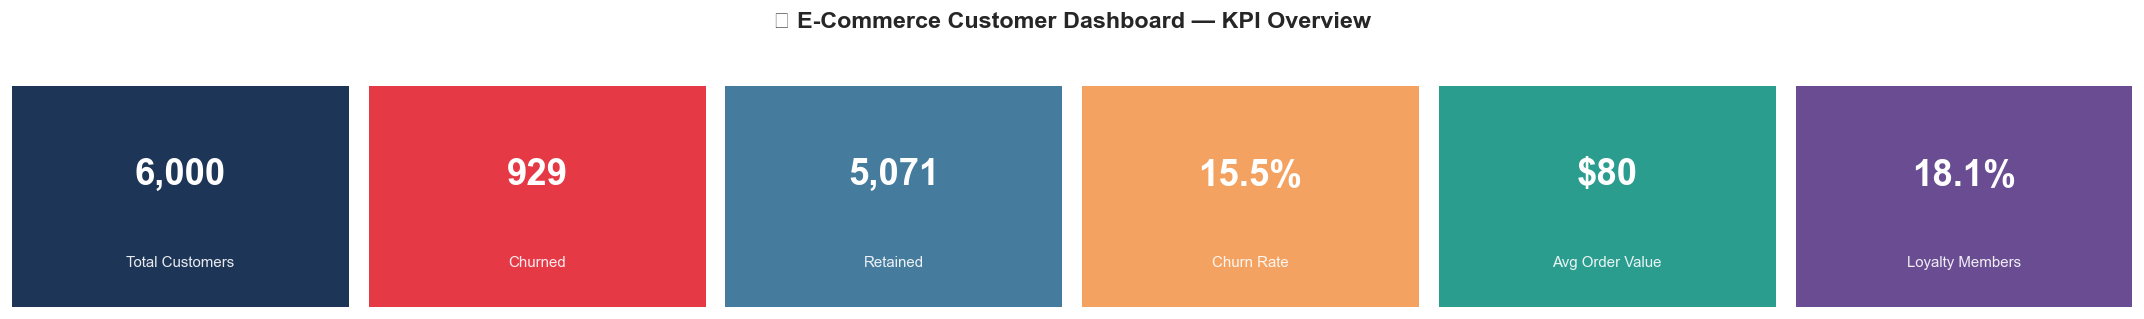

In [ ]:
total      = len(df)
churned_n  = df['churn_flag'].sum()
retained_n = total - churned_n
churn_rate = churned_n / total * 100
avg_order  = df['avg_order_value'].mean()
loyalty_pct= df['loyalty_encoded'].mean() * 100

kpis = [
    ('Total Customers', f'{total:,}', '#1D3557'),
    ('Churned',         f'{churned_n:,}', '#E63946'),
    ('Retained',        f'{retained_n:,}', '#457B9D'),
    ('Churn Rate',      f'{churn_rate:.1f}%', '#F4A261'),
    ('Avg Order Value', f'${avg_order:.0f}', '#2A9D8F'),
    ('Loyalty Members', f'{loyalty_pct:.1f}%', '#6A4C93'),
]

fig, axes = plt.subplots(1, 6, figsize=(18, 2.5))
for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
plt.suptitle('📊 E-Commerce Customer Dashboard — KPI Overview', fontsize=14,
             fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 6. Target Variable Analysis

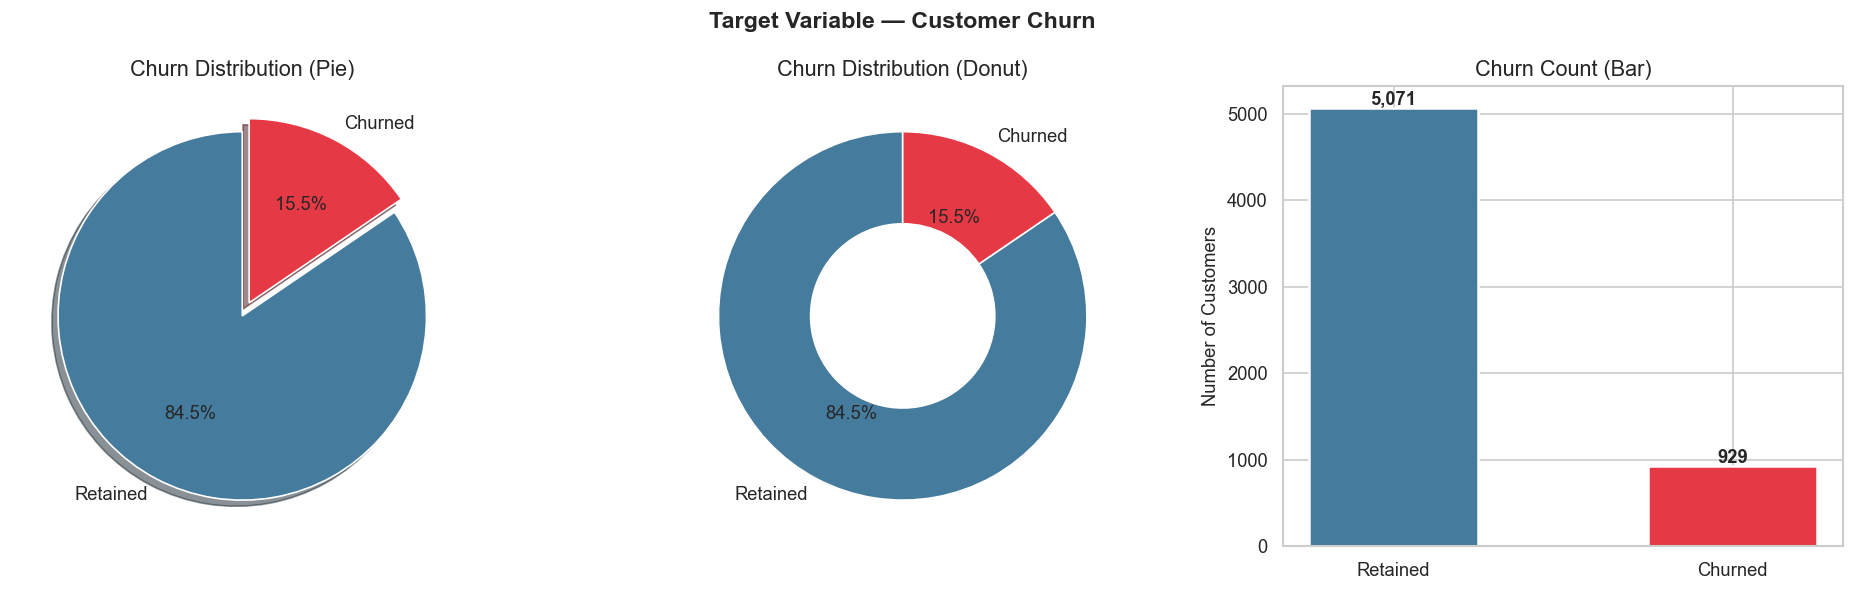

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df['churn_flag'].value_counts()
axes[0].pie(counts, labels=['Retained', 'Churned'],
            colors=[PALETTE['retain'], PALETTE['churn']],
            autopct='%1.1f%%', startangle=90,
            explode=(0, 0.08), shadow=True)
axes[0].set_title('Churn Distribution (Pie)')

axes[1].pie(counts, labels=['Retained', 'Churned'],
            colors=[PALETTE['retain'], PALETTE['churn']],
            autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.5})
axes[1].set_title('Churn Distribution (Donut)')

bars = axes[2].bar(['Retained', 'Churned'], counts.values,
                   color=[PALETTE['retain'], PALETTE['churn']],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')
axes[2].set_title('Churn Count (Bar)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('Target Variable — Customer Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Numeric Feature Distributions

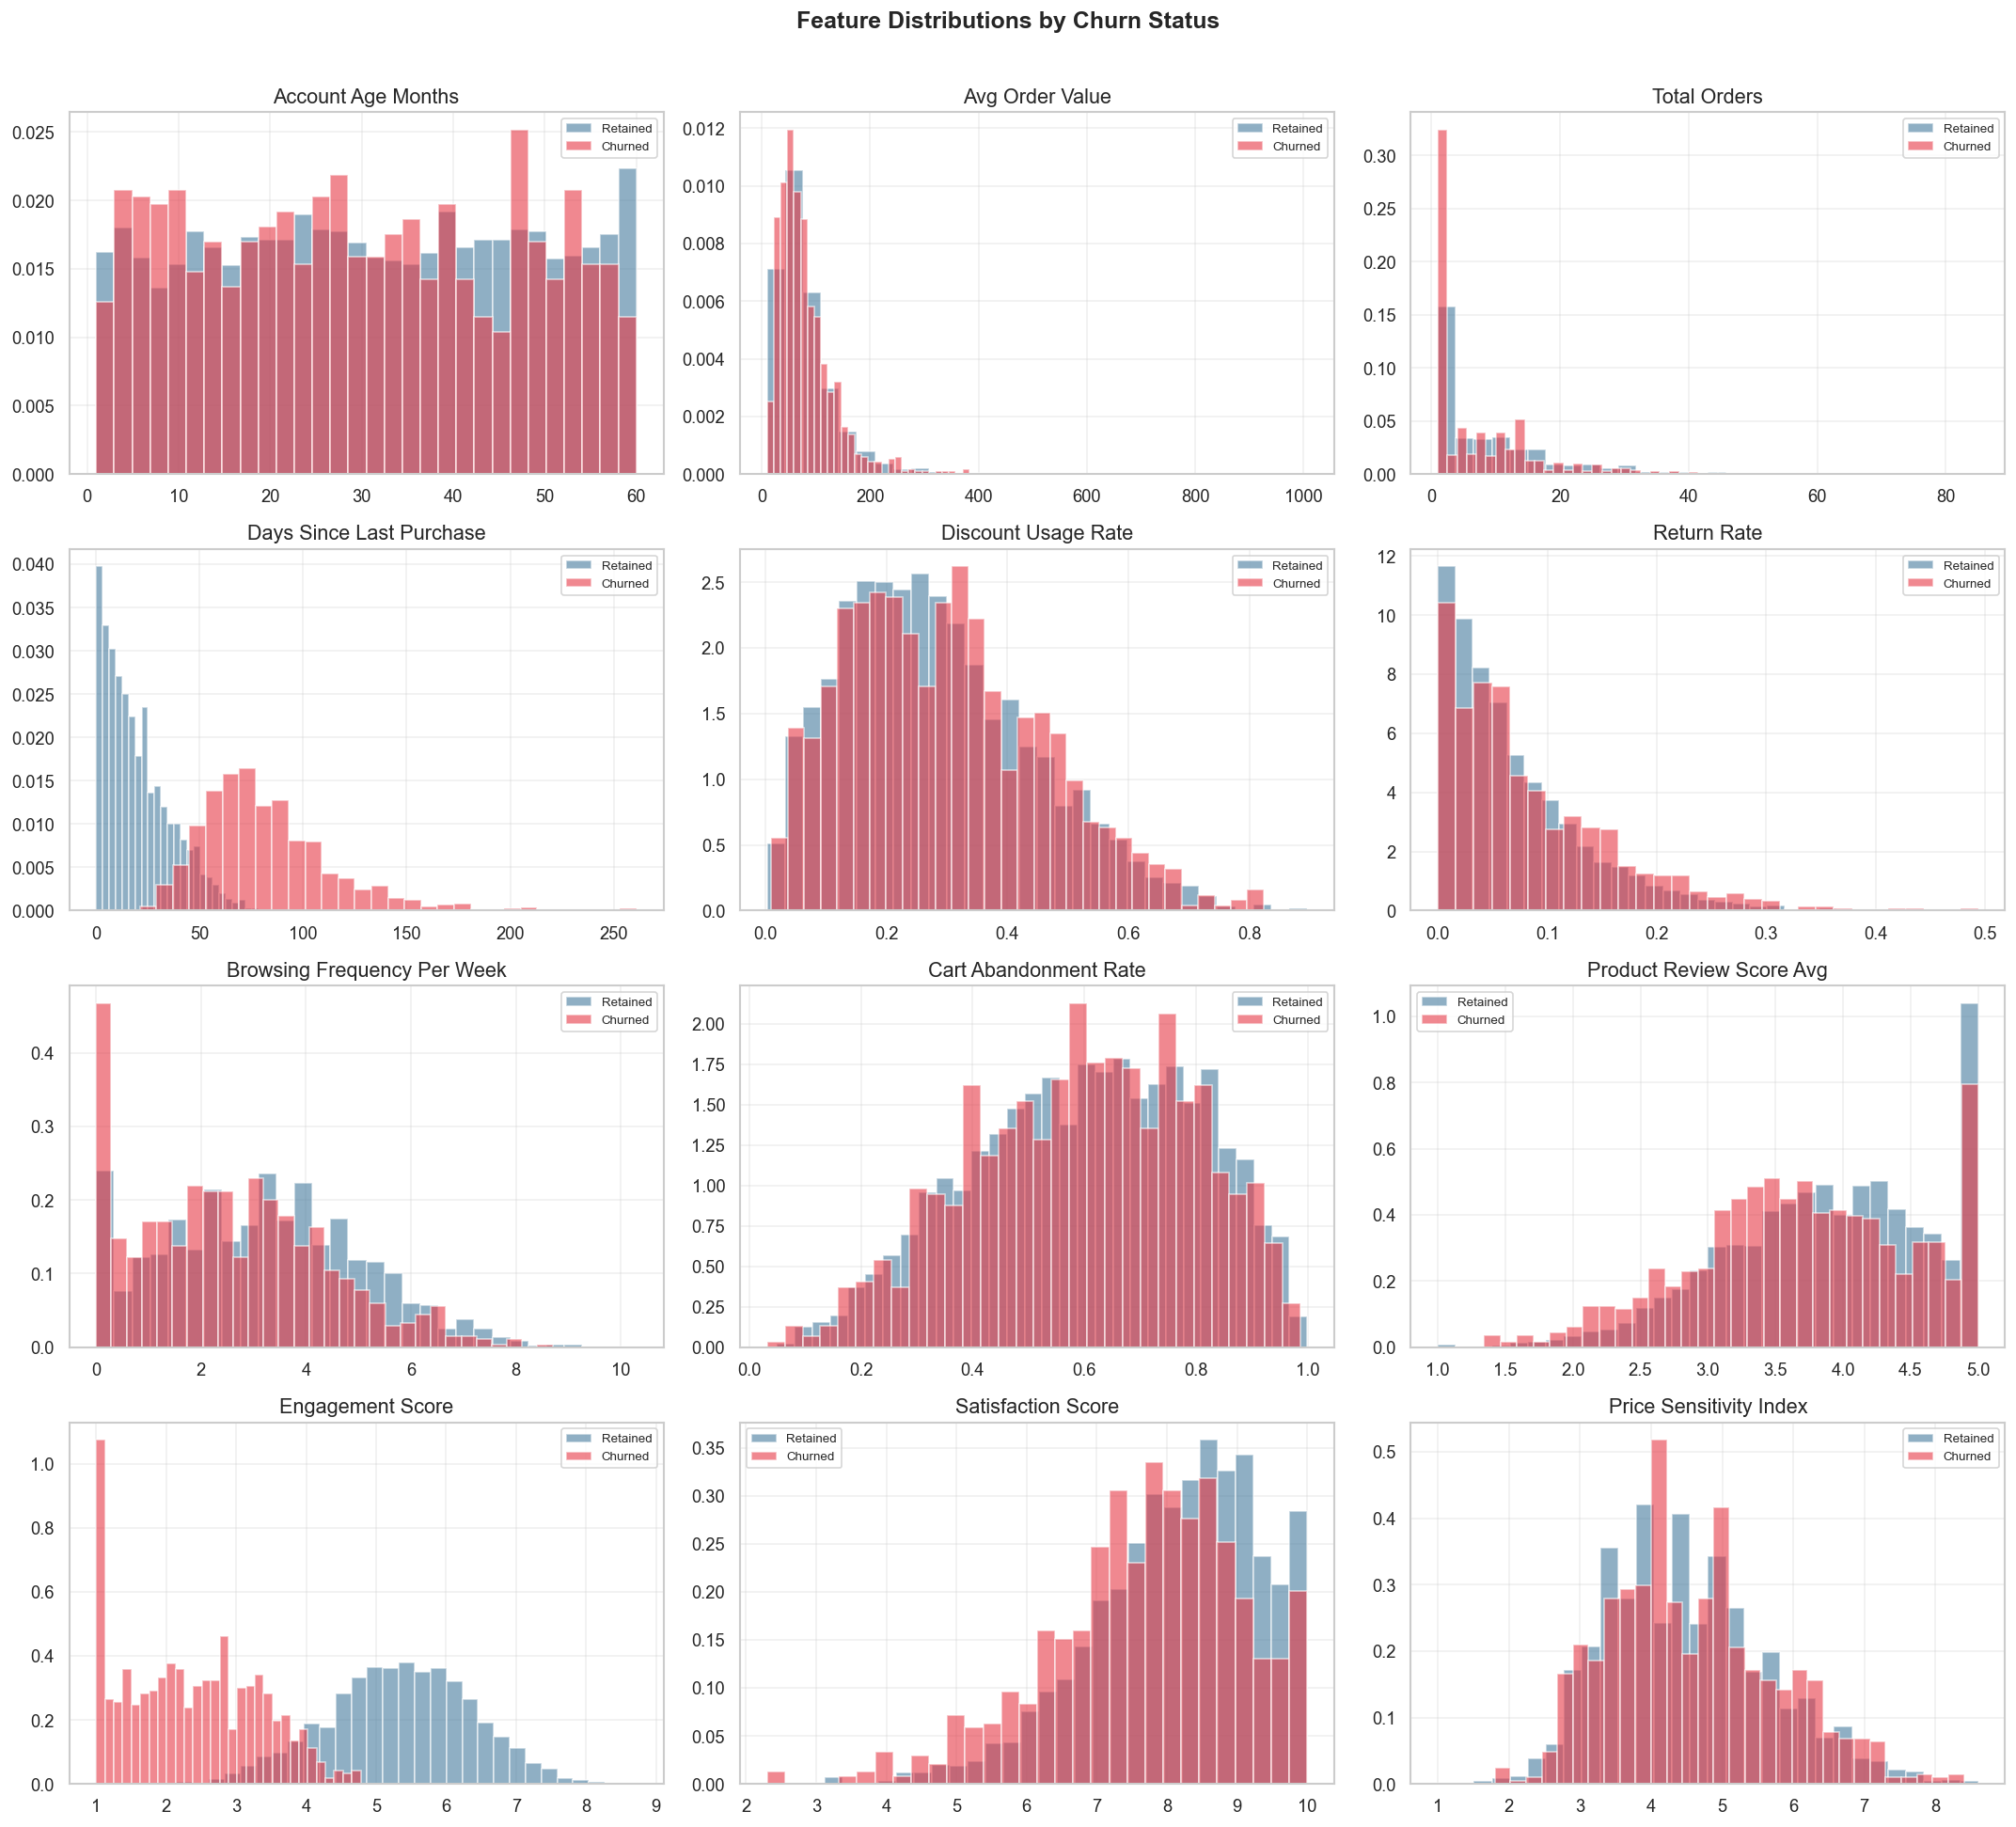

In [7]:
feat_cols = [
    'account_age_months','avg_order_value','total_orders',
    'days_since_last_purchase','discount_usage_rate','return_rate',
    'browsing_frequency_per_week','cart_abandonment_rate',
    'product_review_score_avg','engagement_score',
    'satisfaction_score','price_sensitivity_index'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]
    for val, label, color in [(0,'Retained', PALETTE['retain']),
                               (1,'Churned',  PALETTE['churn'])]:
        subset = df[df['churn_flag'] == val][col]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Churn Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Box Plots — Feature vs Churn

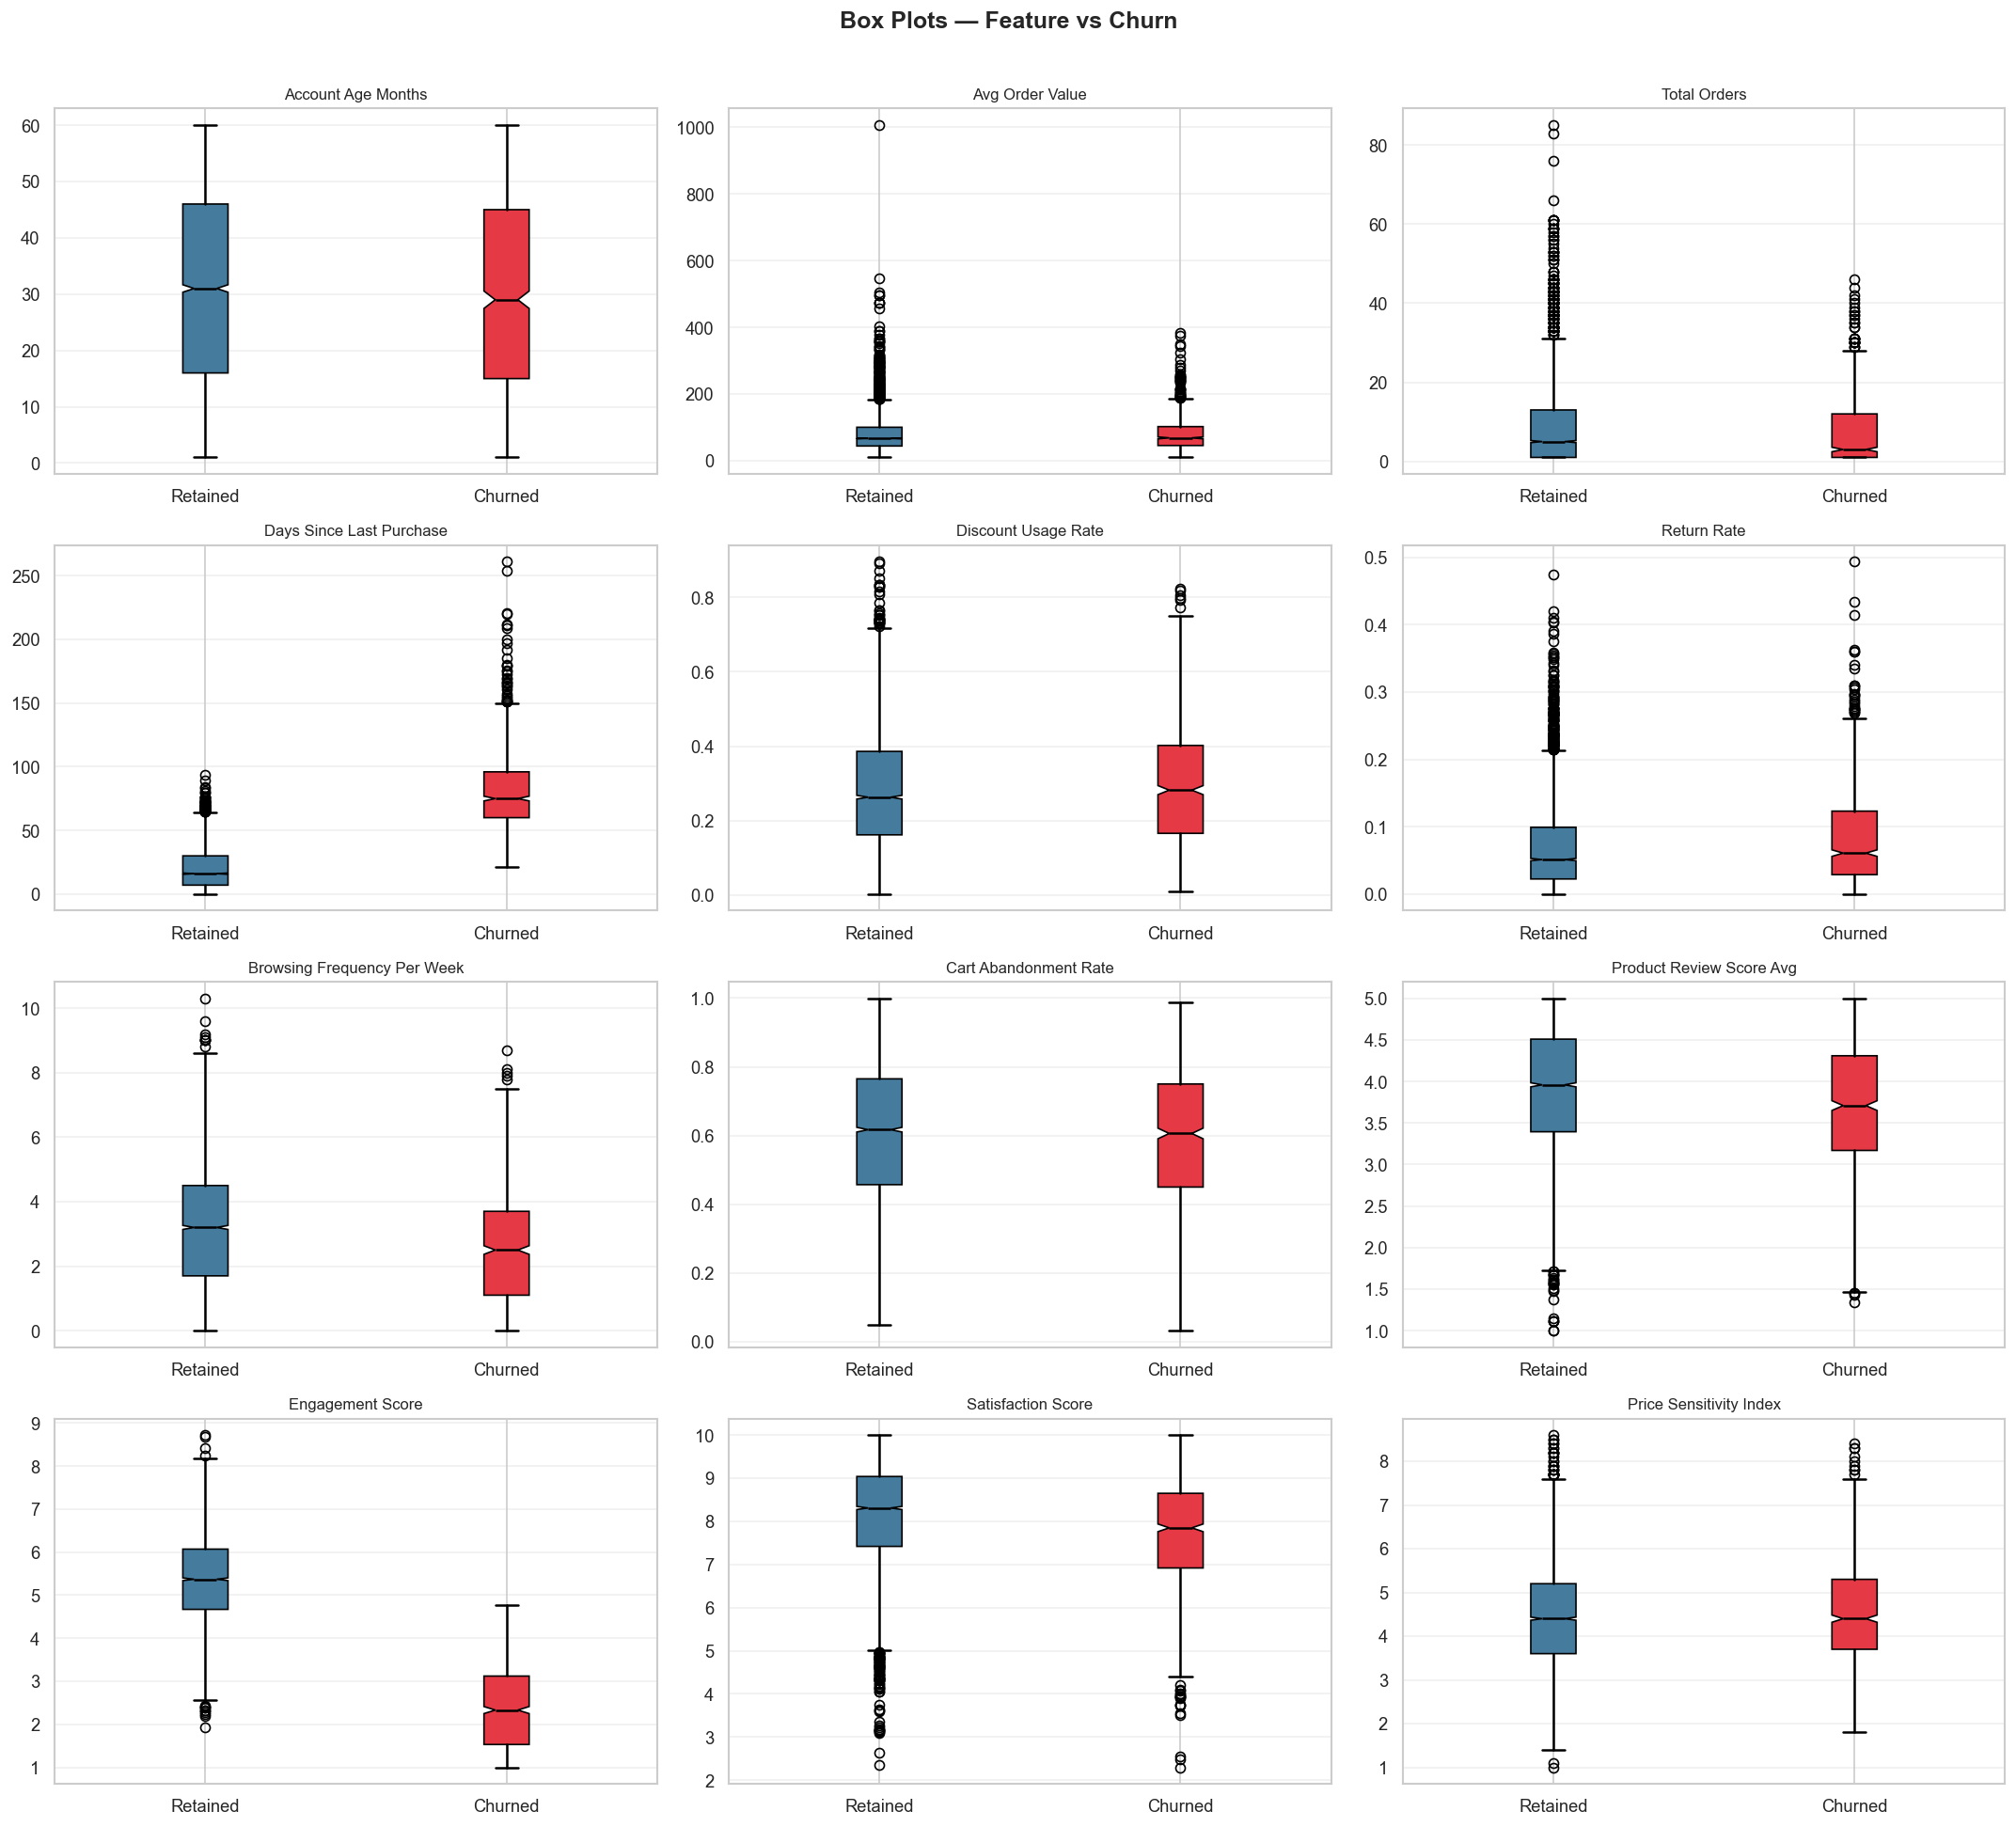

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]
    data_retain = df[df['churn_flag']==0][col]
    data_churn  = df[df['churn_flag']==1][col]
    bp = ax.boxplot([data_retain, data_churn],
                    patch_artist=True,
                    labels=['Retained','Churned'],
                    notch=True)
    bp['boxes'][0].set_facecolor(PALETTE['retain'])
    bp['boxes'][1].set_facecolor(PALETTE['churn'])
    for element in ['whiskers','caps','medians']:
        for patch in bp[element]:
            patch.set_color('black')
            patch.set_linewidth(1.5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Box Plots — Feature vs Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Violin Plots — Deep Distribution View

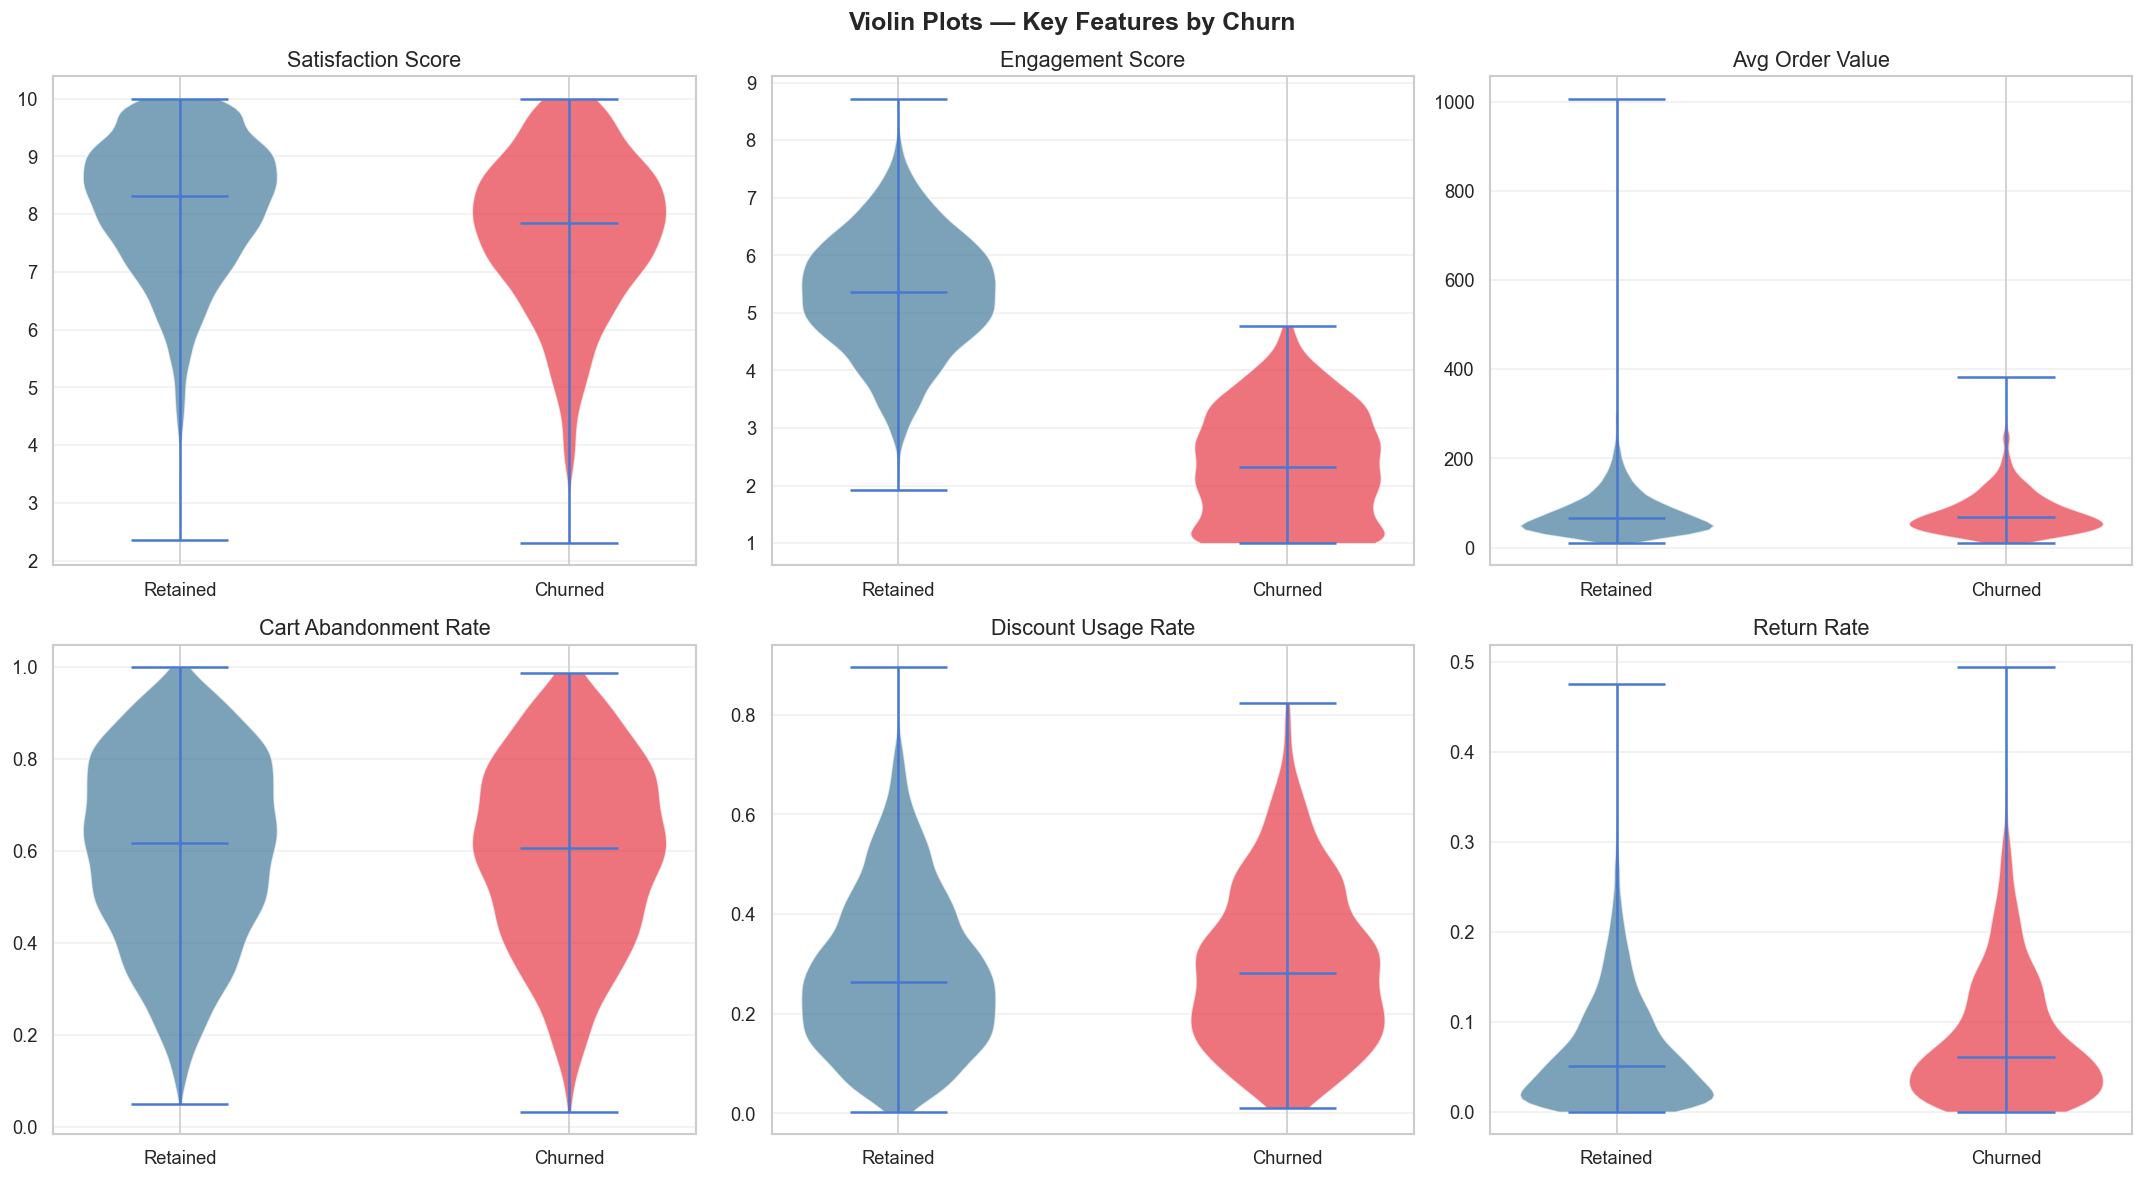

In [9]:
select_cols = [
    'satisfaction_score','engagement_score','avg_order_value',
    'cart_abandonment_rate','discount_usage_rate','return_rate'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(select_cols):
    ax = axes[i]
    data = [df[df['churn_flag']==0][col].values,
            df[df['churn_flag']==1][col].values]
    parts = ax.violinplot(data, positions=[1, 2], showmedians=True,
                          showextrema=True)
    parts['bodies'][0].set_facecolor(PALETTE['retain'])
    parts['bodies'][1].set_facecolor(PALETTE['churn'])
    for body in parts['bodies']:
        body.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(col.replace('_', ' ').title())
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Violin Plots — Key Features by Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Correlation Heatmap

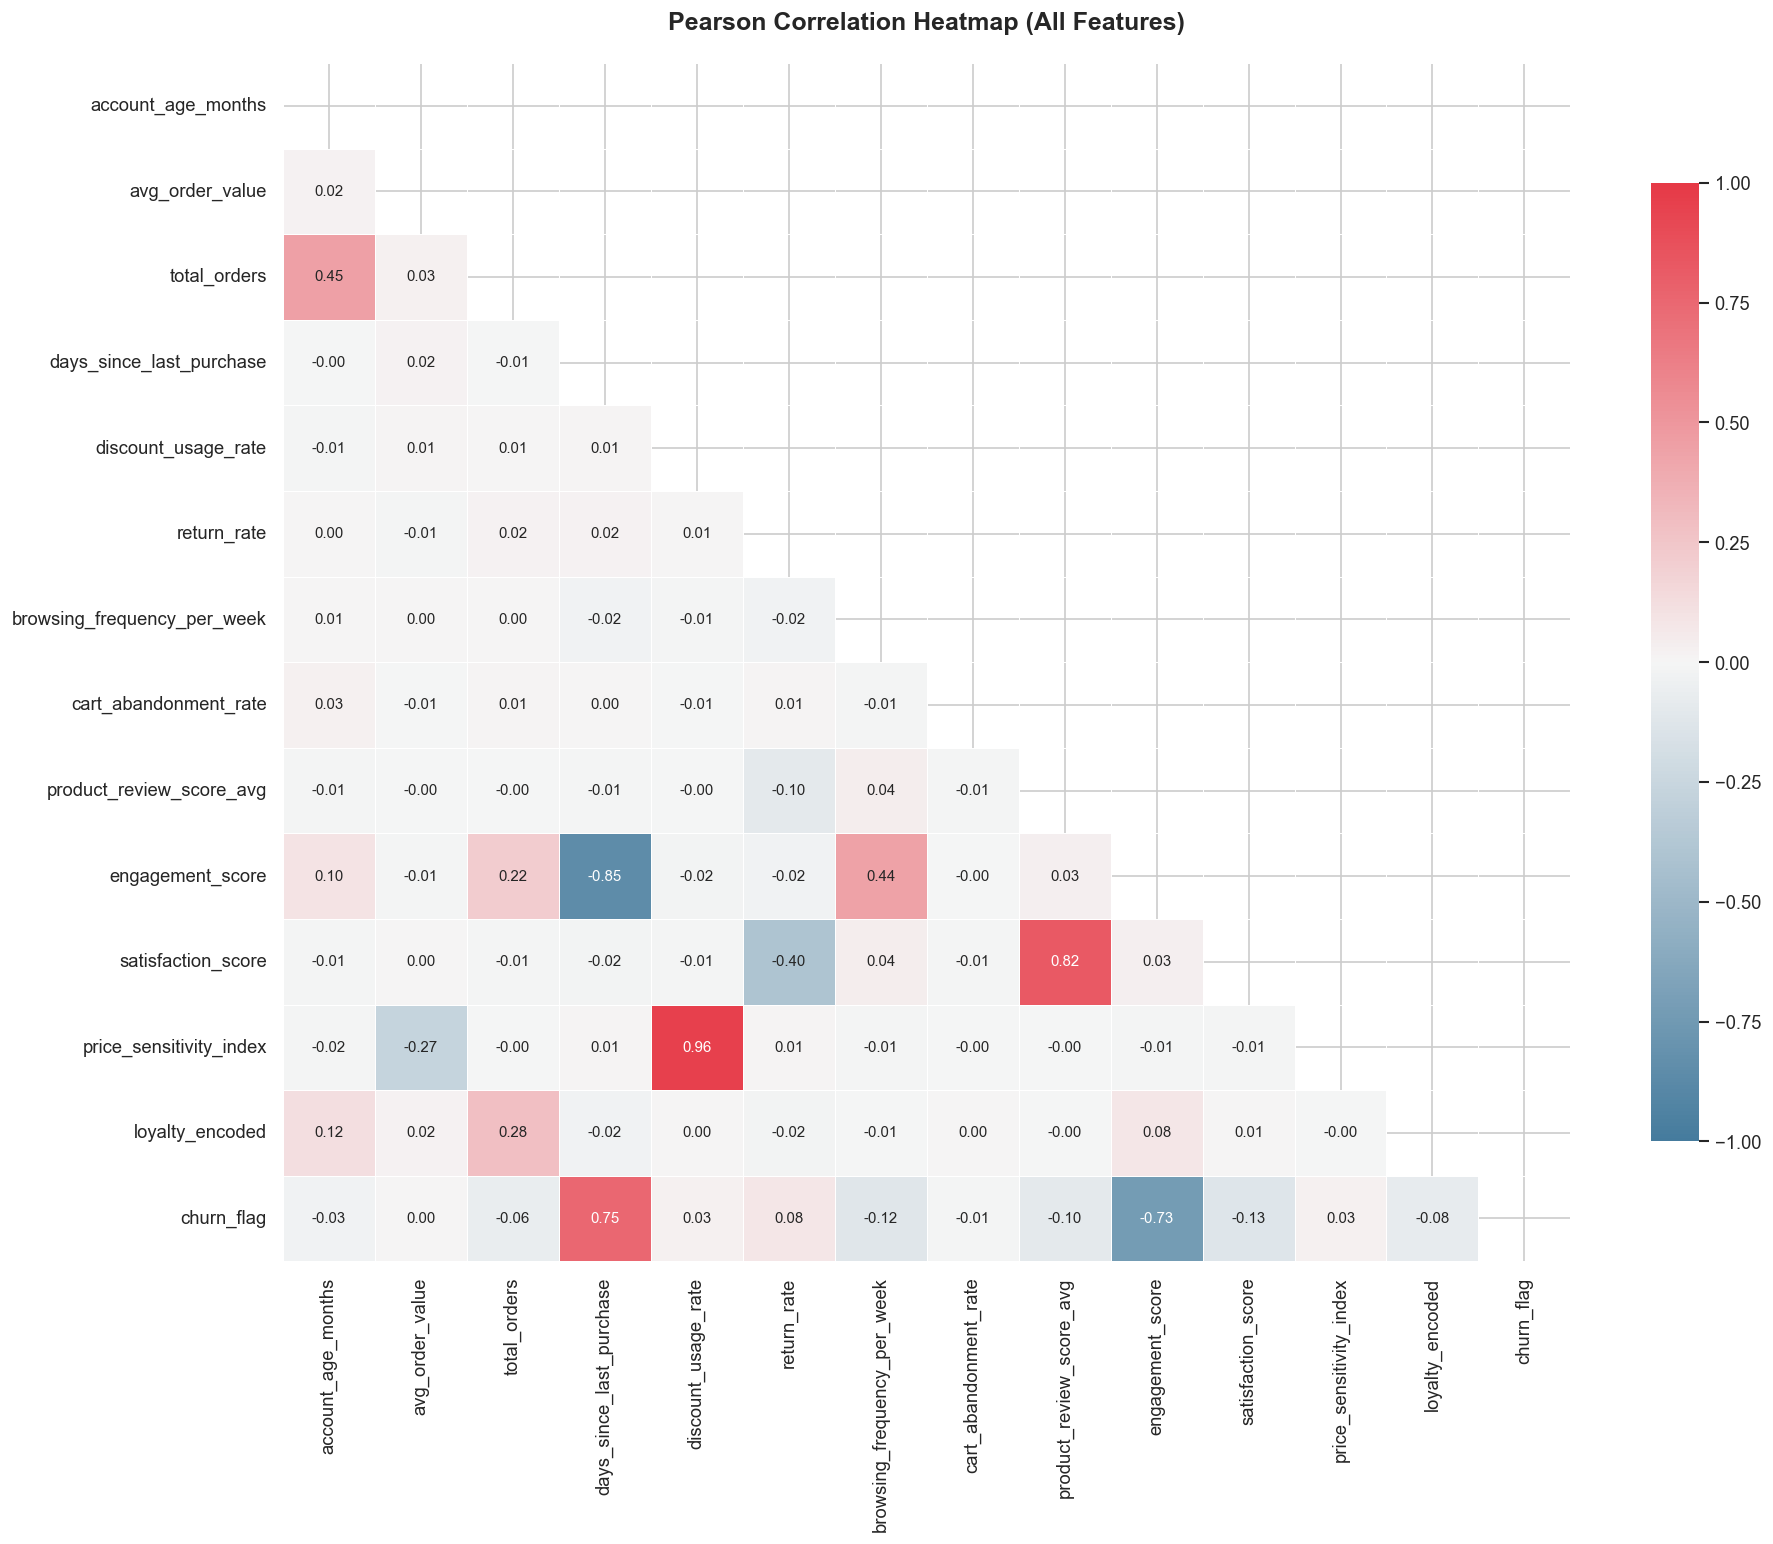

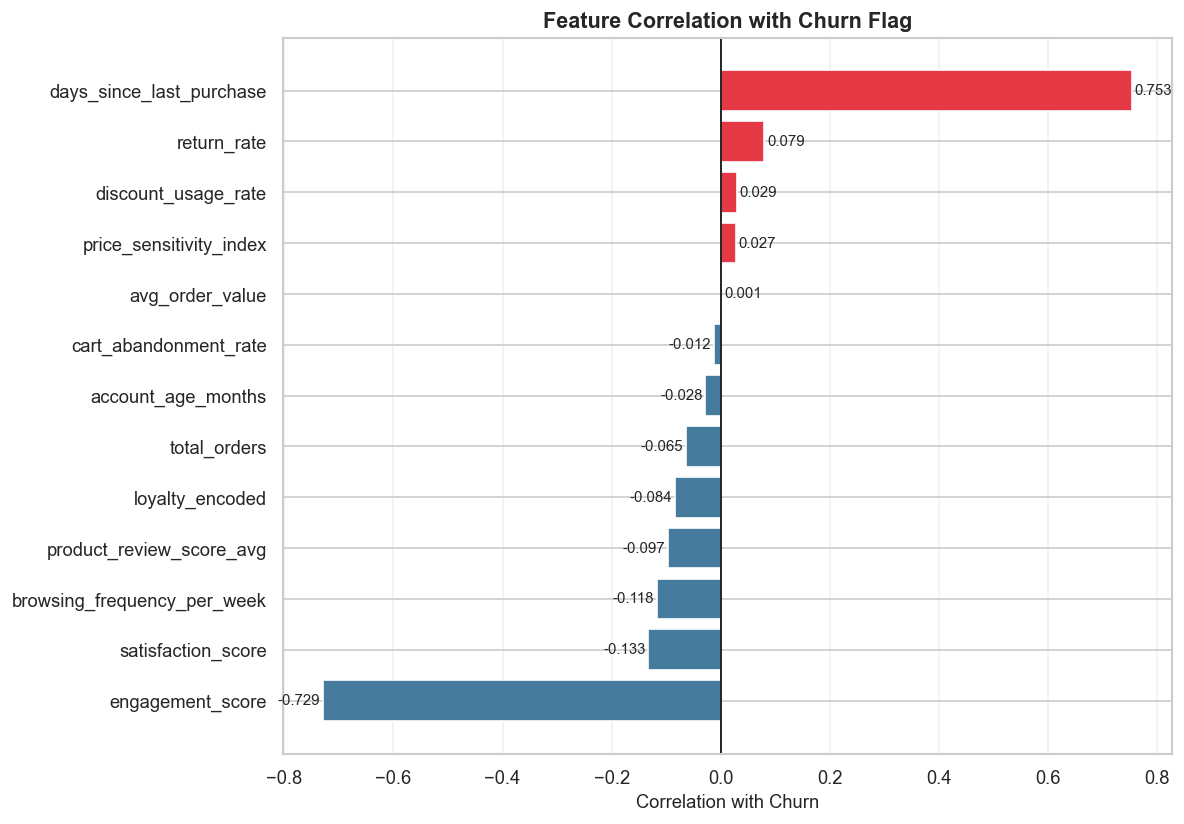

In [ ]:
corr_cols = feat_cols + ['loyalty_encoded', 'churn_flag']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = LinearSegmentedColormap.from_list('churn_cmap',
    ['#457B9D', '#F5F5F5', '#E63946'])
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=cmap, center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Pearson Correlation Heatmap (All Features)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

churn_corr = corr['churn_flag'].drop('churn_flag').sort_values()
colors = [PALETTE['churn'] if v > 0 else PALETTE['retain'] for v in churn_corr]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, churn_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Correlation with Churn')
ax.set_title('Feature Correlation with Churn Flag', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Categorical Feature Analysis

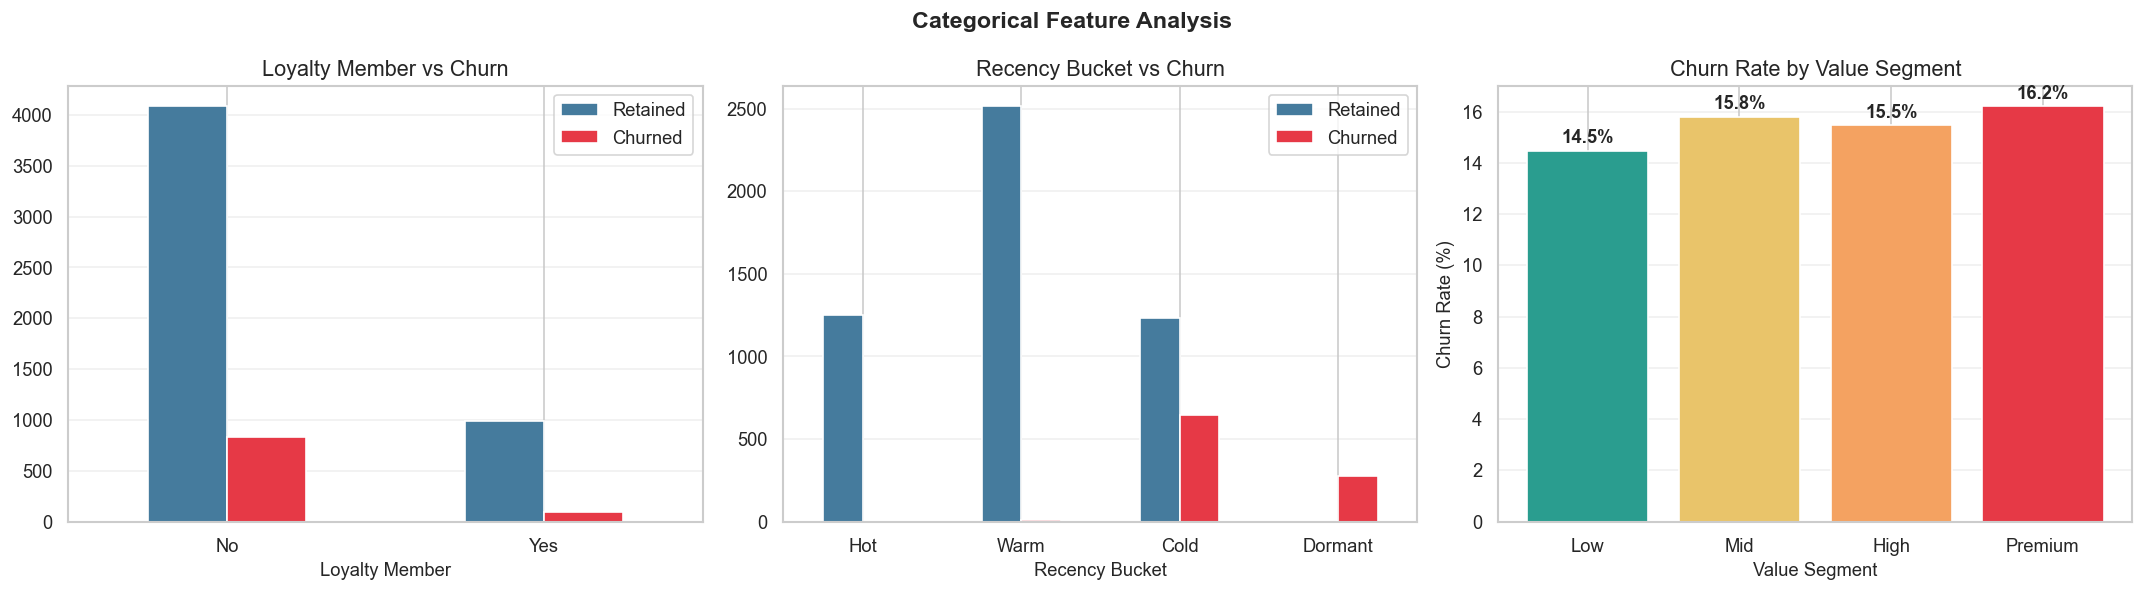

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

loyalty_churn = df.groupby(['loyalty_member','churned']).size().unstack(fill_value=0)
loyalty_churn.plot(kind='bar', ax=axes[0],
                   color=[PALETTE['retain'], PALETTE['churn']],
                   edgecolor='white', rot=0)
axes[0].set_title('Loyalty Member vs Churn')
axes[0].set_xlabel('Loyalty Member')
axes[0].legend(['Retained','Churned'])
axes[0].grid(True, axis='y', alpha=0.3)

rec_churn = df.groupby(['recency_bucket','churn_flag']).size().unstack(fill_value=0)
rec_churn.plot(kind='bar', ax=axes[1],
               color=[PALETTE['retain'], PALETTE['churn']],
               edgecolor='white', rot=0)
axes[1].set_title('Recency Bucket vs Churn')
axes[1].set_xlabel('Recency Bucket')
axes[1].legend(['Retained','Churned'])
axes[1].grid(True, axis='y', alpha=0.3)

seg_rate = df.groupby('value_segment')['churn_flag'].mean() * 100
colors_seg = ['#2A9D8F','#E9C46A','#F4A261','#E63946']
bars = axes[2].bar(seg_rate.index, seg_rate.values, color=colors_seg, edgecolor='white')
for bar, val in zip(bars, seg_rate.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Churn Rate by Value Segment')
axes[2].set_xlabel('Value Segment')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle('Categorical Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Scatter Plots — Multi-dimension Relationships

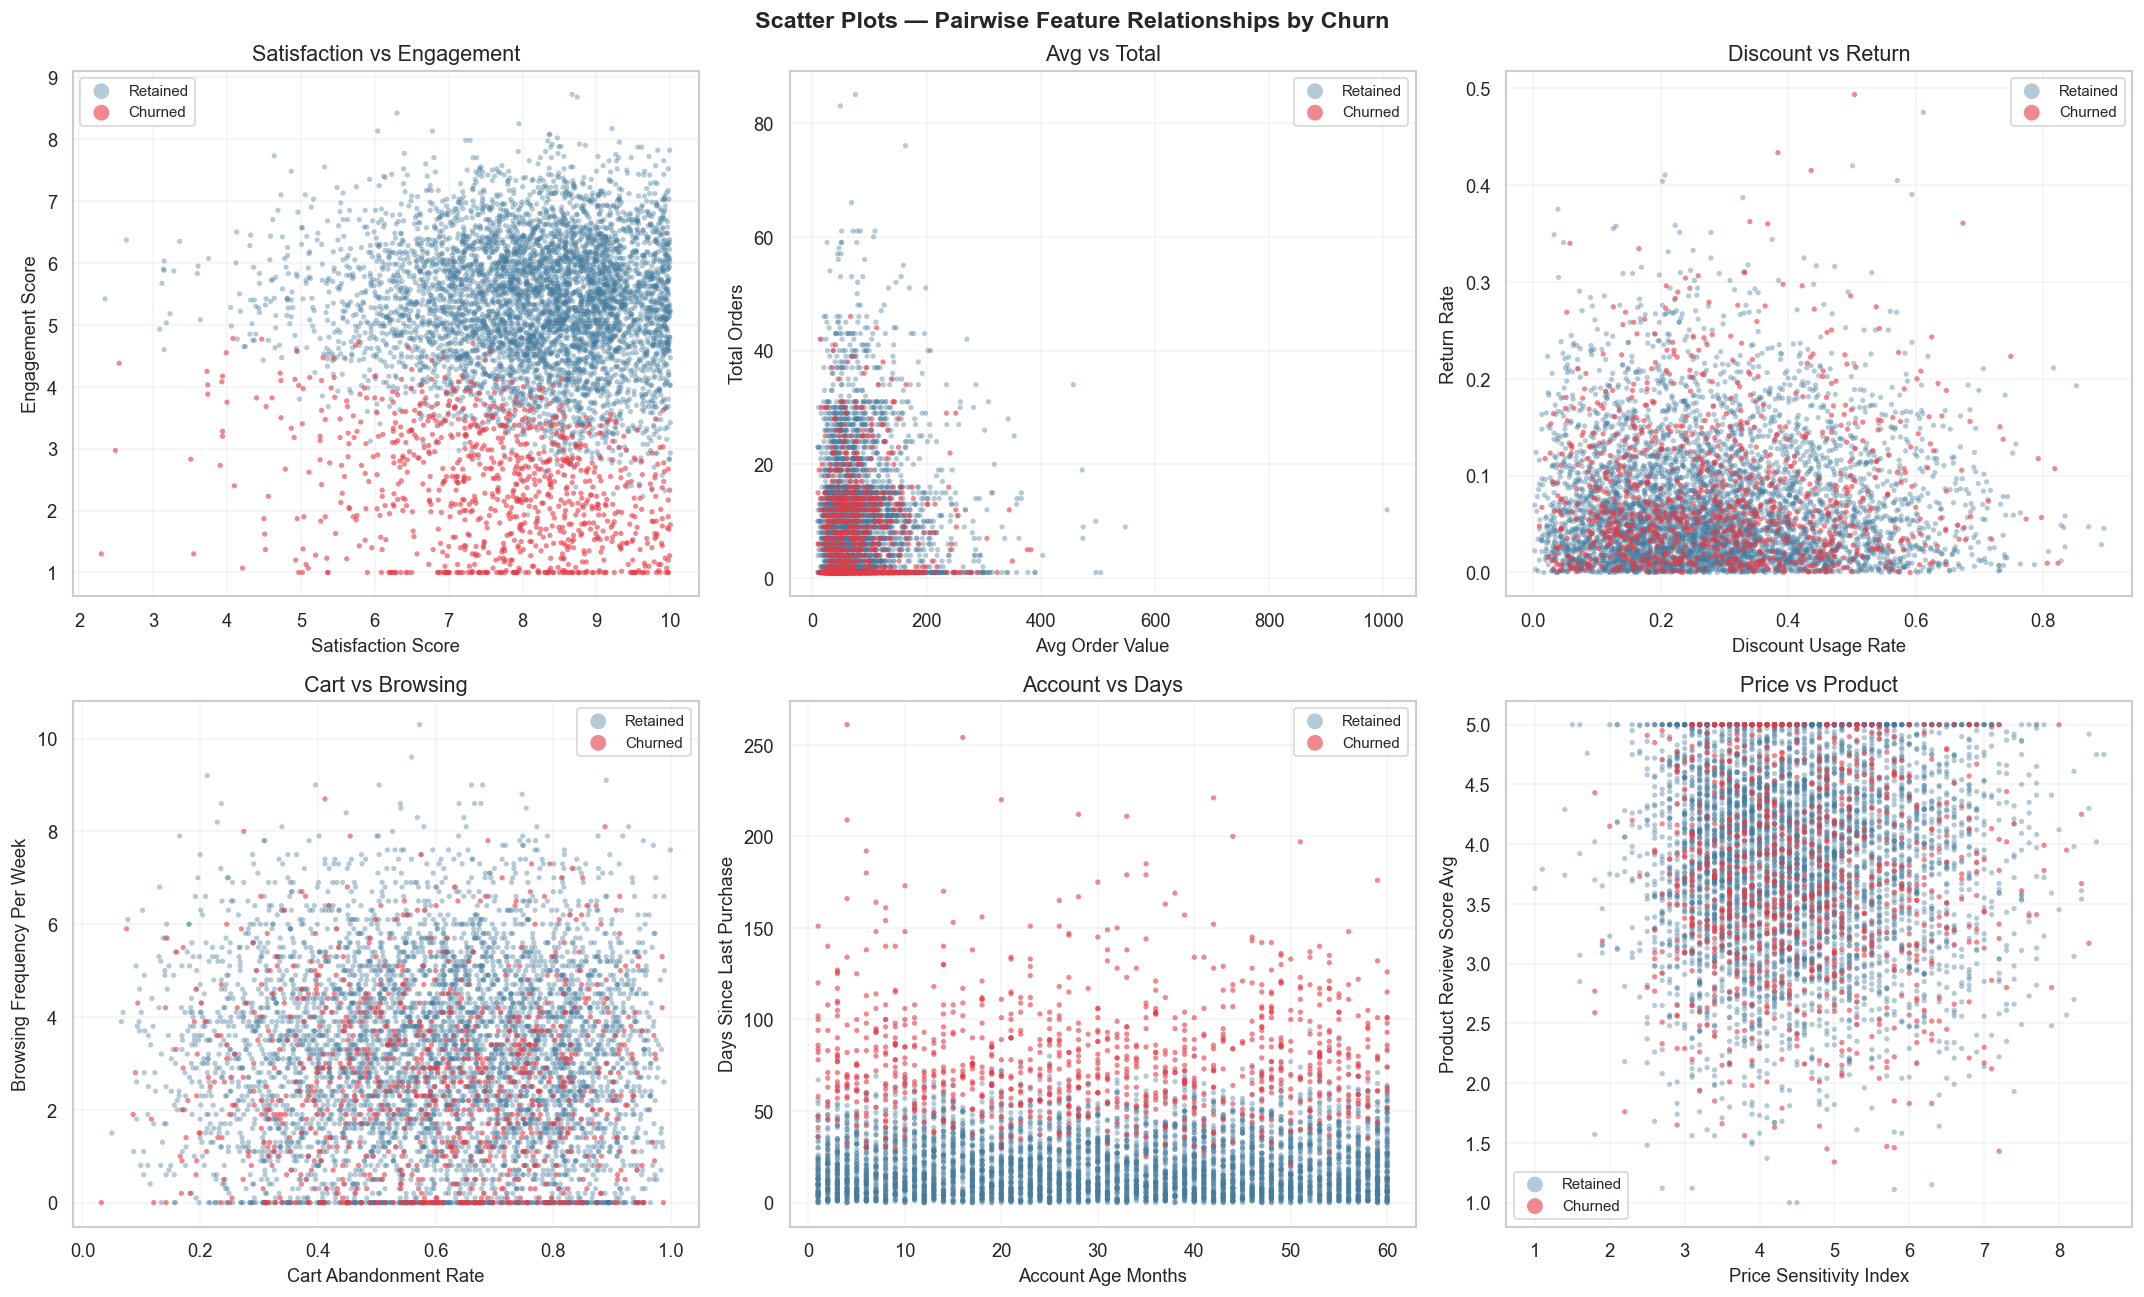

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
pairs = [
    ('satisfaction_score',    'engagement_score'),
    ('avg_order_value',       'total_orders'),
    ('discount_usage_rate',   'return_rate'),
    ('cart_abandonment_rate', 'browsing_frequency_per_week'),
    ('account_age_months',    'days_since_last_purchase'),
    ('price_sensitivity_index','product_review_score_avg'),
]

for i, (x_col, y_col) in enumerate(pairs):
    ax = axes[i]
    for flag, label, color, alpha in [(0,'Retained',PALETTE['retain'],0.4),
                                       (1,'Churned', PALETTE['churn'], 0.6)]:
        sub = df[df['churn_flag']==flag]
        ax.scatter(sub[x_col], sub[y_col], c=color, label=label,
                   alpha=alpha, s=10, edgecolors='none')
    ax.set_xlabel(x_col.replace('_',' ').title())
    ax.set_ylabel(y_col.replace('_',' ').title())
    ax.set_title(f'{x_col.split("_")[0].title()} vs {y_col.split("_")[0].title()}')
    ax.legend(markerscale=3, fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Scatter Plots — Pairwise Feature Relationships by Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Advanced Visualisations — Pair Grid & Radar

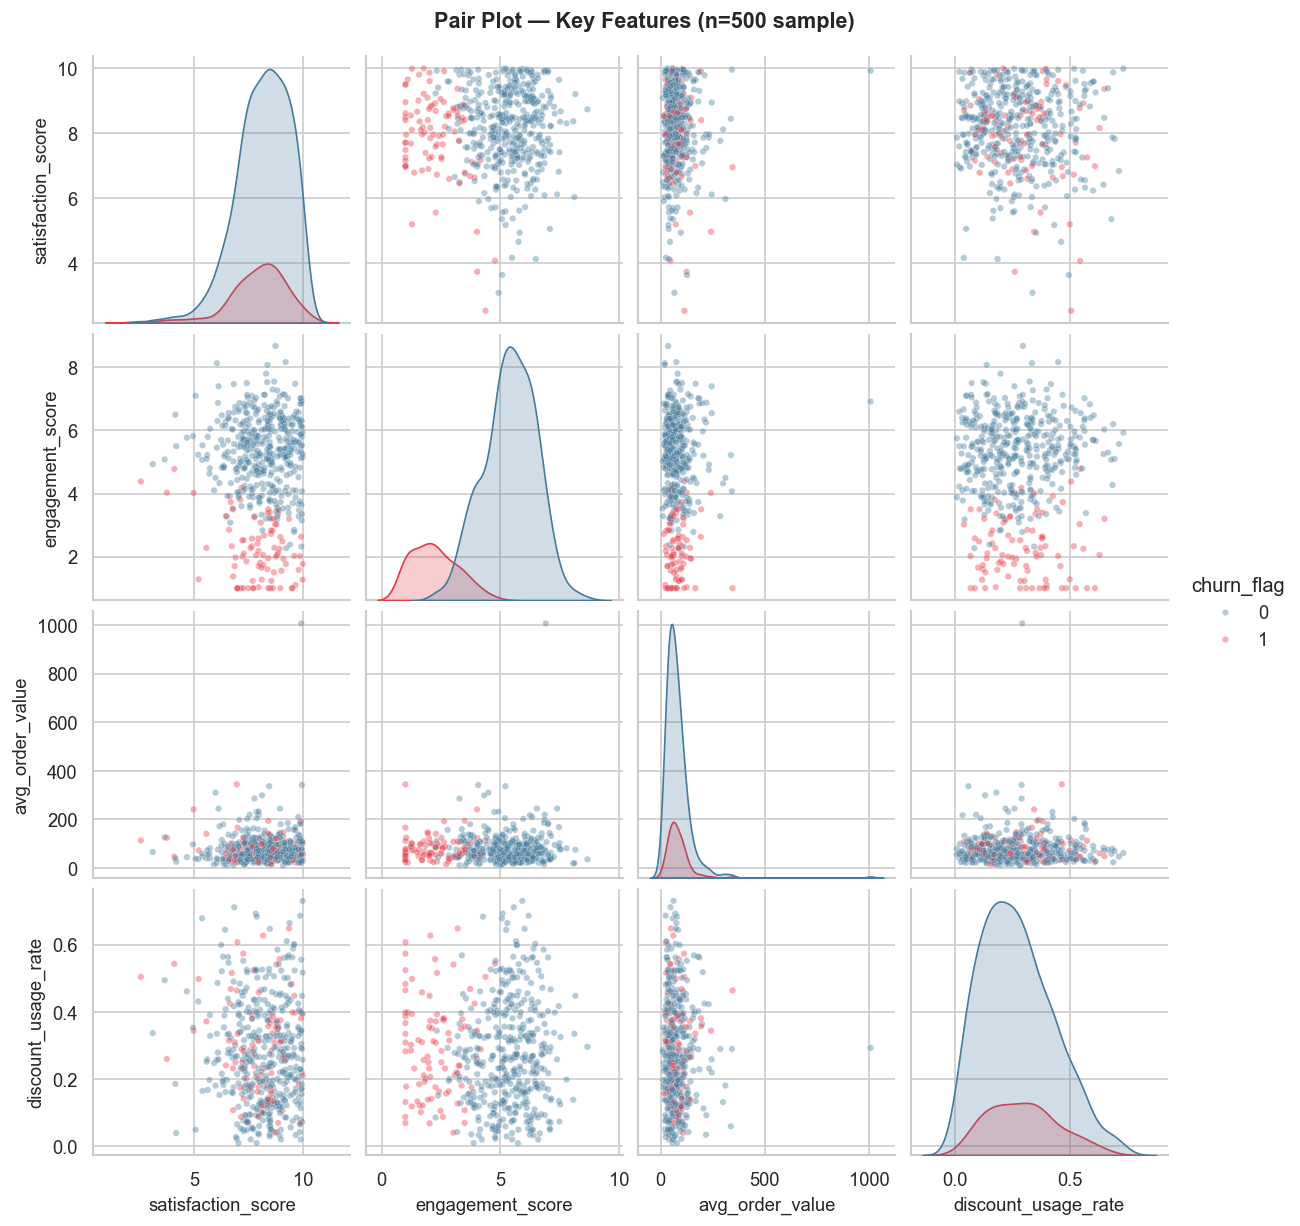

In [ ]:
pair_cols = ['satisfaction_score','engagement_score','avg_order_value',
             'discount_usage_rate','churn_flag']
sample = df[pair_cols].sample(500, random_state=42)
g = sns.pairplot(sample, hue='churn_flag', diag_kind='kde',
                 palette={0: PALETTE['retain'], 1: PALETTE['churn']},
                 plot_kws={'alpha': 0.4, 's': 15},
                 vars=['satisfaction_score','engagement_score',
                       'avg_order_value','discount_usage_rate'])
g.fig.suptitle('Pair Plot — Key Features (n=500 sample)',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

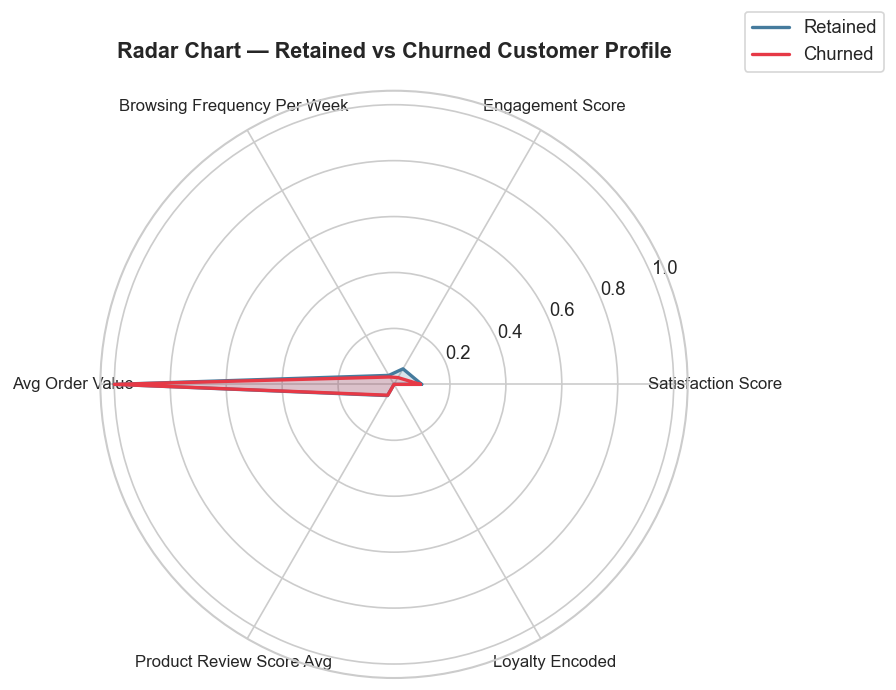

In [ ]:
radar_cols = [
    'satisfaction_score','engagement_score','browsing_frequency_per_week',
    'avg_order_value','product_review_score_avg','loyalty_encoded'
]

def normalize_radar(df, cols):
    means_r = df[df['churn_flag']==0][cols].mean()
    means_c = df[df['churn_flag']==1][cols].mean()
    combined = pd.DataFrame({'Retained': means_r, 'Churned': means_c})
    return (combined - combined.min()) / (combined.max() - combined.min() + 1e-9)

norm = normalize_radar(df, radar_cols)
N = len(radar_cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
for col, color, label in [('Retained', PALETTE['retain'], 'Retained'),
                            ('Churned',  PALETTE['churn'],  'Churned')]:
    vals = norm[col].tolist() + norm[col].tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('_',' ').title() for c in radar_cols], fontsize=10)
ax.set_title('Radar Chart — Retained vs Churned Customer Profile',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

## 14. Stacked & Grouped Bar — Churn Rate by Segments

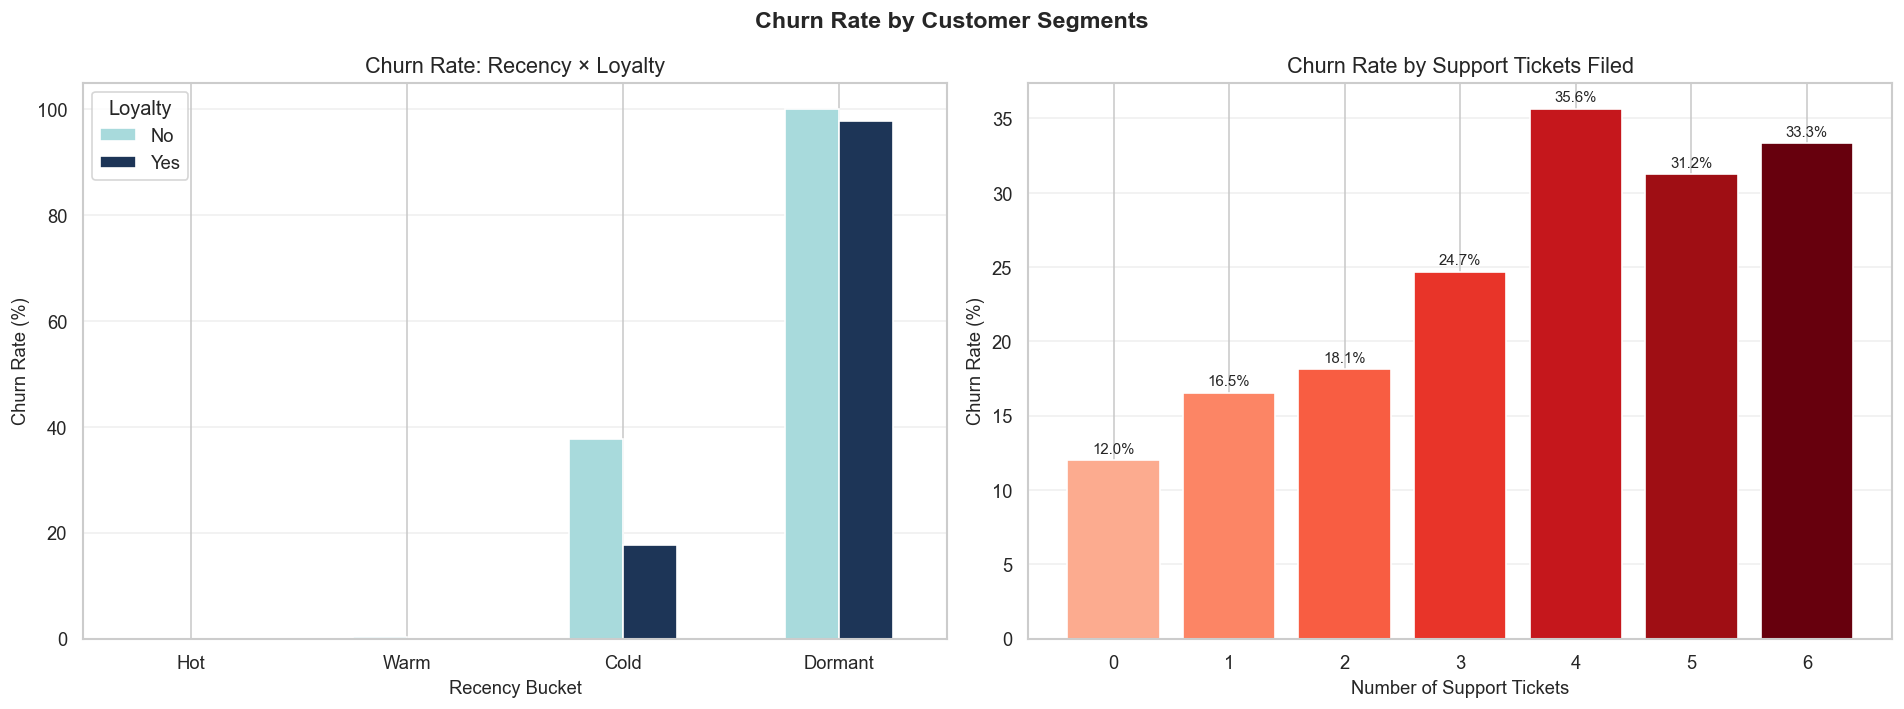

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot = df.groupby(['recency_bucket','loyalty_member'])['churn_flag'].mean().unstack() * 100
pivot.plot(kind='bar', stacked=False, ax=axes[0],
           color=['#A8DADC','#1D3557'], edgecolor='white', rot=0)
axes[0].set_title('Churn Rate: Recency × Loyalty')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Recency Bucket')
axes[0].legend(title='Loyalty')
axes[0].grid(True, axis='y', alpha=0.3)

ticket_churn = df.groupby('customer_support_tickets')['churn_flag'].mean() * 100
colors_t = plt.cm.Reds(np.linspace(0.3, 1.0, len(ticket_churn)))
axes[1].bar(ticket_churn.index, ticket_churn.values, color=colors_t, edgecolor='white')
for x, y in zip(ticket_churn.index, ticket_churn.values):
    axes[1].text(x, y + 0.5, f'{y:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Churn Rate by Support Tickets Filed')
axes[1].set_xlabel('Number of Support Tickets')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Churn Rate by Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. PCA + K-Means Clustering

PCA explained variance: PC1=20.5%, PC2=13.3%


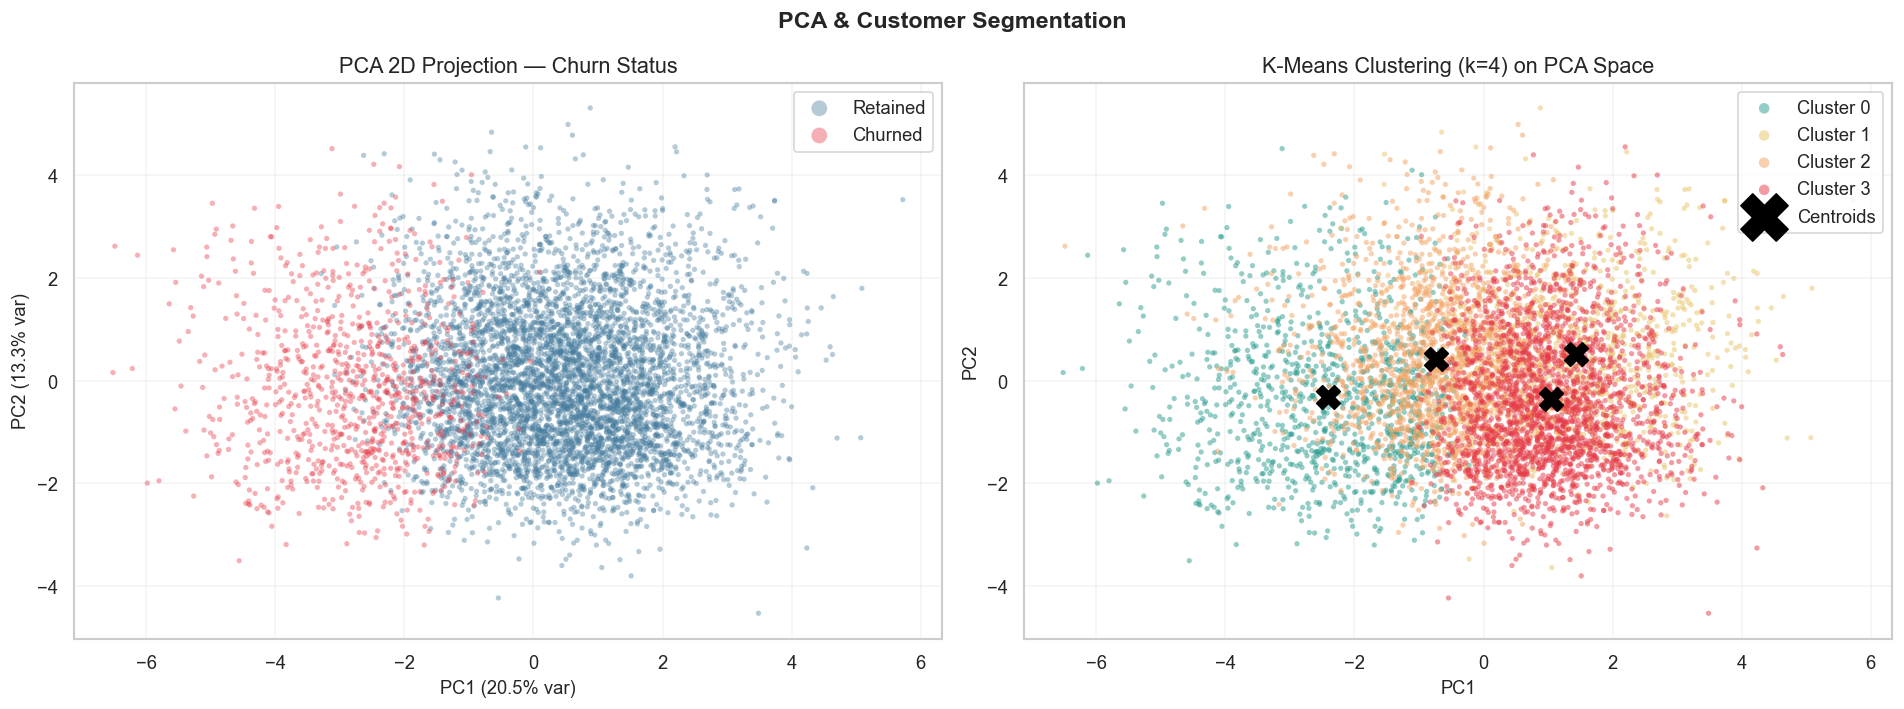


Cluster Summary:
         n_customers  churn_rate  avg_order_value  satisfaction  \
cluster                                                           
0               1085       0.716           81.789         8.183   
1                935       0.013           82.914         8.252   
2               1622       0.085           79.382         6.742   
3               2358       0.001           79.689         8.858   

         churn_rate_pct  
cluster                  
0                  71.6  
1                   1.3  
2                   8.5  
3                   0.1  


In [ ]:
ml_cols = feat_cols + ['loyalty_encoded','orders_per_month',
                        'engagement_x_satisfaction']
X_all = df[ml_cols].copy()
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_all)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%,'
      f' PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

km = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = km.fit_predict(X_scaled)
df['cluster'] = clusters

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for flag, label, color in [(0,'Retained',PALETTE['retain']),(1,'Churned',PALETTE['churn'])]:
    mask = df['churn_flag'] == flag
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
                    alpha=0.4, s=10, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('PCA 2D Projection — Churn Status')
axes[0].legend(markerscale=3)
axes[0].grid(True, alpha=0.2)

cluster_colors = ['#2A9D8F','#E9C46A','#F4A261','#E63946']
for c in range(4):
    mask = clusters == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=cluster_colors[c],
                    label=f'Cluster {c}', alpha=0.5, s=10, edgecolors='none')

centroids_pca = pca.transform(km.cluster_centers_)
axes[1].scatter(centroids_pca[:,0], centroids_pca[:,1], c='black',
                marker='X', s=200, zorder=5, label='Centroids')
axes[1].set_xlabel(f'PC1')
axes[1].set_ylabel(f'PC2')
axes[1].set_title('K-Means Clustering (k=4) on PCA Space')
axes[1].legend(markerscale=2)
axes[1].grid(True, alpha=0.2)

plt.suptitle('PCA & Customer Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

cluster_summary = df.groupby('cluster').agg(
    n_customers=('churn_flag','count'),
    churn_rate=('churn_flag','mean'),
    avg_order_value=('avg_order_value','mean'),
    satisfaction=('satisfaction_score','mean')
).round(3)
cluster_summary['churn_rate_pct'] = (cluster_summary['churn_rate']*100).round(1)
print('\nCluster Summary:')
print(cluster_summary)

## 16. Elbow Chart + Silhouette for K Selection

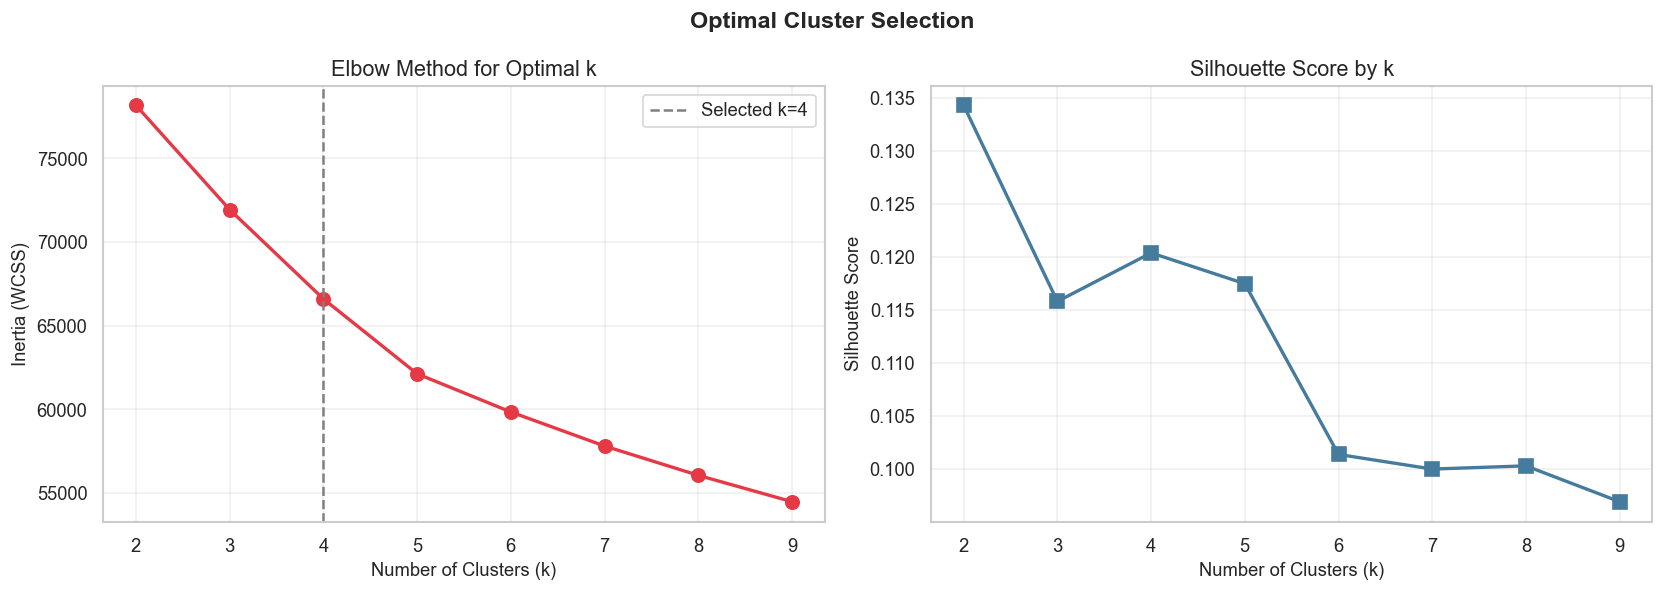

In [17]:
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(2, 10)
for k in K_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_temp.fit_predict(X_scaled)
    inertias.append(km_temp.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'o-', color=PALETTE['churn'], linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(4, color='grey', linestyle='--', label='Selected k=4')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 's-', color=PALETTE['retain'], linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimal Cluster Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Model Training — Build Features & Split

In [ ]:
feature_cols = feat_cols + [
    'loyalty_encoded',
    'orders_per_month',
    'engagement_x_satisfaction',
    'support_heavy'
]

X = df[feature_cols].copy()
y = df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set    : {X_test.shape[0]:,} samples')
print(f'Churn rate (train): {y_train.mean()*100:.1f}%')
print(f'Churn rate (test) : {y_test.mean()*100:.1f}%')

Training set: 4,800 samples
Test set    : 1,200 samples
Churn rate (train): 15.5%
Churn rate (test) : 15.5%


## 18. Train Multiple Classifiers

In [19]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=9),
    'Naive Bayes'         : GaussianNB(),
    'SVM'                 : SVC(probability=True, random_state=42, class_weight='balanced'),
}

results = {}
for name, clf in models.items():
    if name in ['KNN','SVM','Naive Bayes']:
        clf.fit(X_train_s, y_train)
        y_pred  = clf.predict(X_test_s)
        y_prob  = clf.predict_proba(X_test_s)[:,1]
    else:
        clf.fit(X_train, y_train)
        y_pred  = clf.predict(X_test)
        y_prob  = clf.predict_proba(X_test)[:,1]
    results[name] = {
        'model'    : clf,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'accuracy' : accuracy_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
    }
    print(f'{name:22s} | Acc={results[name]["accuracy"]:.3f}'
          f' | F1={results[name]["f1"]:.3f}'
          f' | ROC-AUC={results[name]["roc_auc"]:.3f}')

Logistic Regression    | Acc=0.961 | F1=0.885 | ROC-AUC=0.994
Decision Tree          | Acc=0.953 | F1=0.860 | ROC-AUC=0.959
Random Forest          | Acc=0.971 | F1=0.902 | ROC-AUC=0.990
Gradient Boosting      | Acc=0.968 | F1=0.895 | ROC-AUC=0.993
KNN                    | Acc=0.949 | F1=0.813 | ROC-AUC=0.980
Naive Bayes            | Acc=0.944 | F1=0.840 | ROC-AUC=0.990
SVM                    | Acc=0.954 | F1=0.867 | ROC-AUC=0.992


## 19. Model Comparison Plots

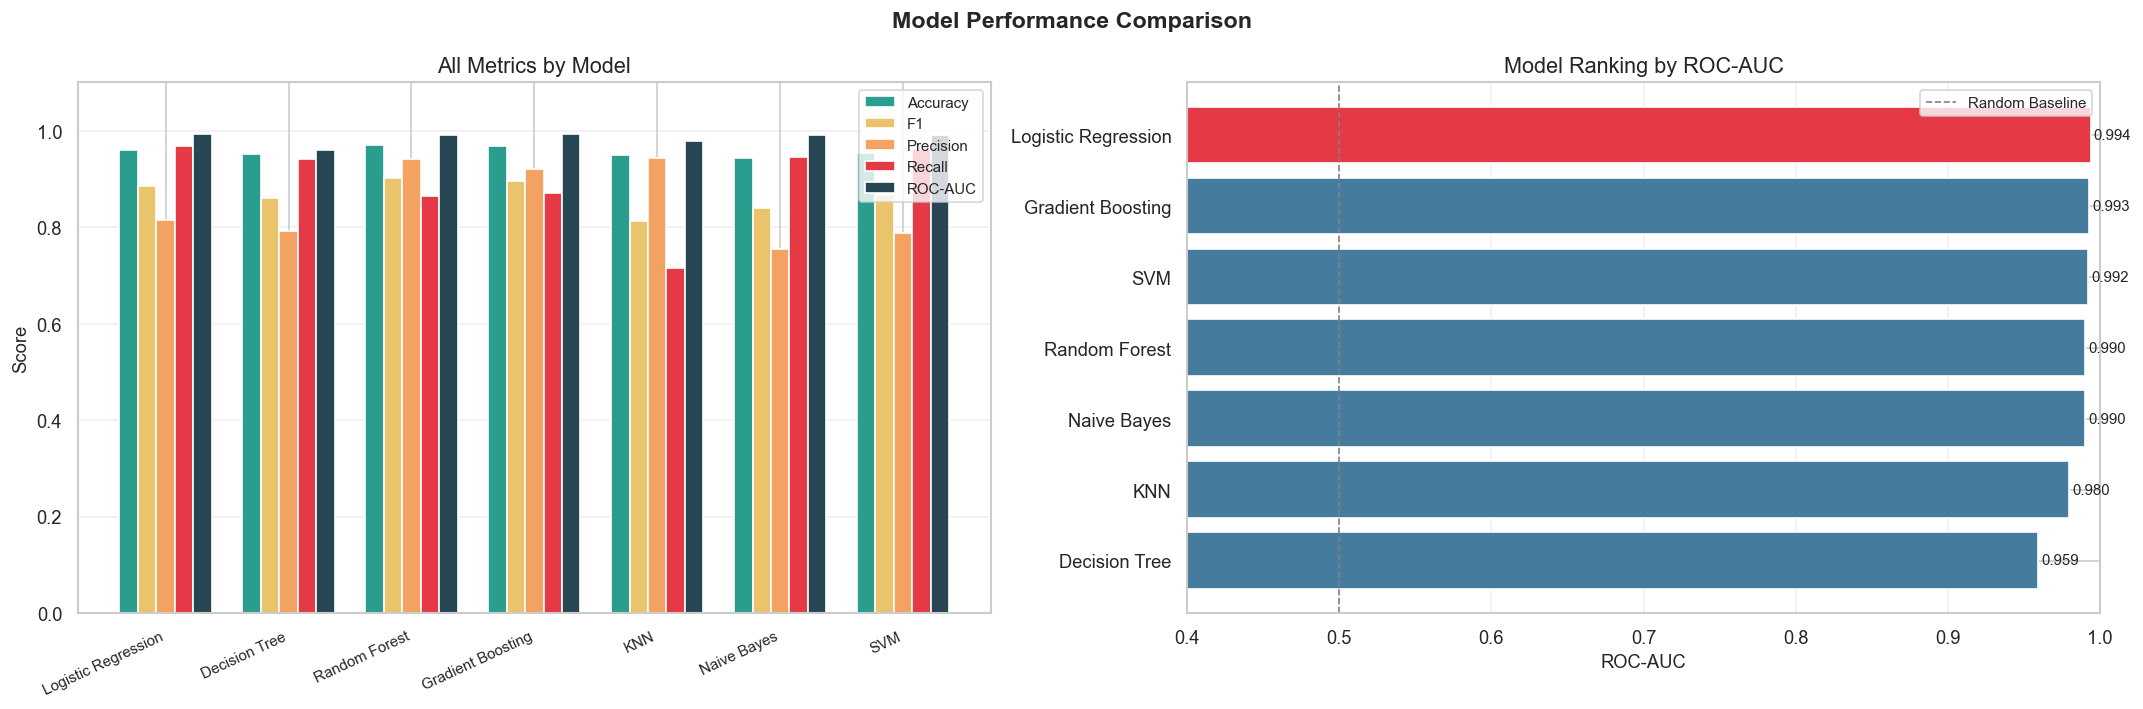

In [ ]:
metrics = ['accuracy','f1','precision','recall','roc_auc']
metric_labels = ['Accuracy','F1','Precision','Recall','ROC-AUC']
model_names = list(results.keys())

scores = {m: [results[n][m] for n in model_names] for m in metrics}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(model_names))
w = 0.15
bar_colors = ['#2A9D8F','#E9C46A','#F4A261','#E63946','#264653']
for i, (m, label) in enumerate(zip(metrics, metric_labels)):
    axes[0].bar(x + i*w, scores[m], w, label=label, color=bar_colors[i], edgecolor='white')
axes[0].set_xticks(x + 2*w)
axes[0].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics by Model')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

auc_vals  = [(n, results[n]['roc_auc']) for n in model_names]
auc_vals.sort(key=lambda x: x[1])
names_s, vals_s = zip(*auc_vals)
c_bar = [PALETTE['churn'] if v == max(vals_s) else PALETTE['retain'] for v in vals_s]
axes[1].barh(names_s, vals_s, color=c_bar, edgecolor='white')
for name, val in zip(names_s, vals_s):
    axes[1].text(val + 0.002, names_s.index(name), f'{val:.3f}', va='center', fontsize=9)
axes[1].set_xlim(0.4, 1.0)
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('Model Ranking by ROC-AUC')
axes[1].axvline(0.5, color='grey', linestyle='--', linewidth=1, label='Random Baseline')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='x', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 20. ROC Curves — All Models

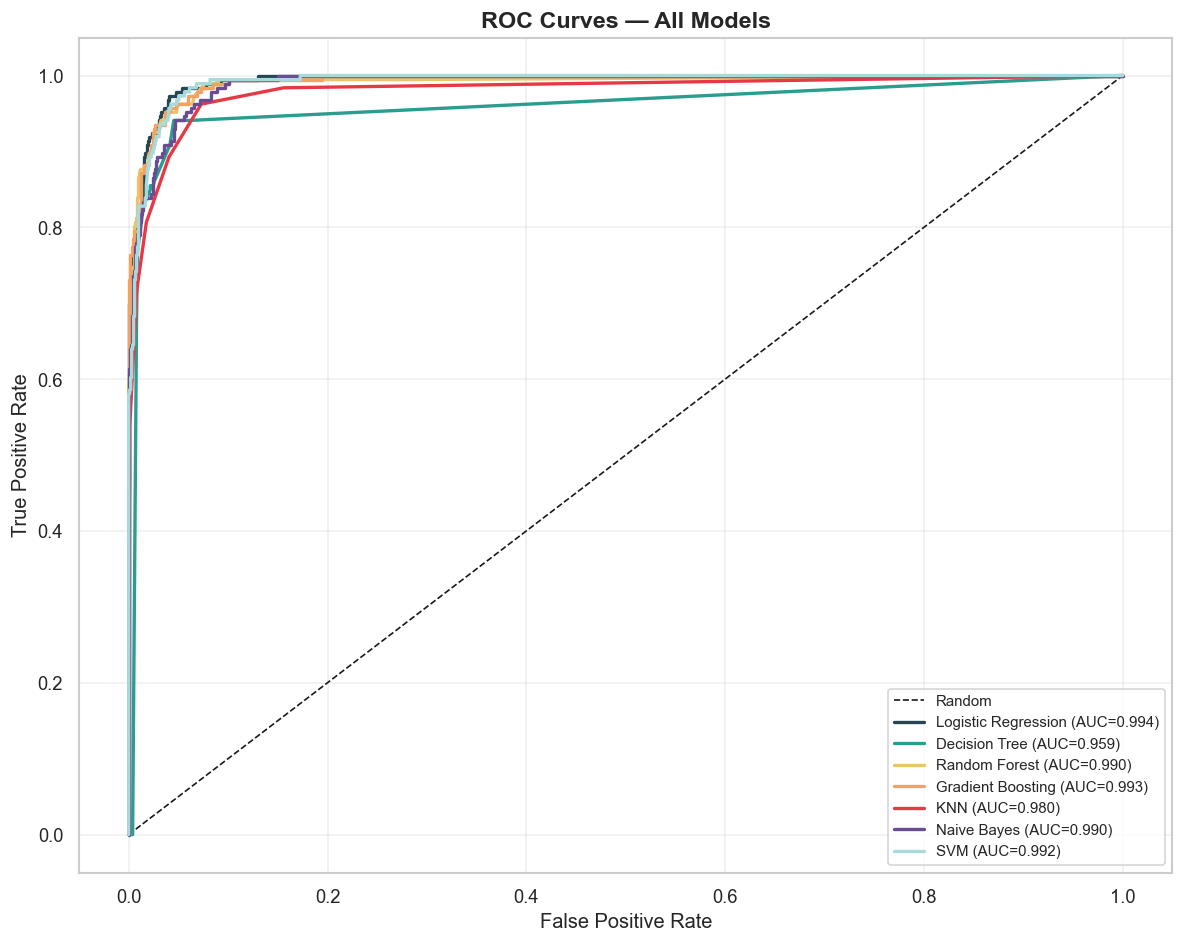

In [21]:
colors_roc = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E63946','#6A4C93','#A8DADC']

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f"{name} (AUC={res['roc_auc']:.3f})")

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 21. Precision-Recall Curves

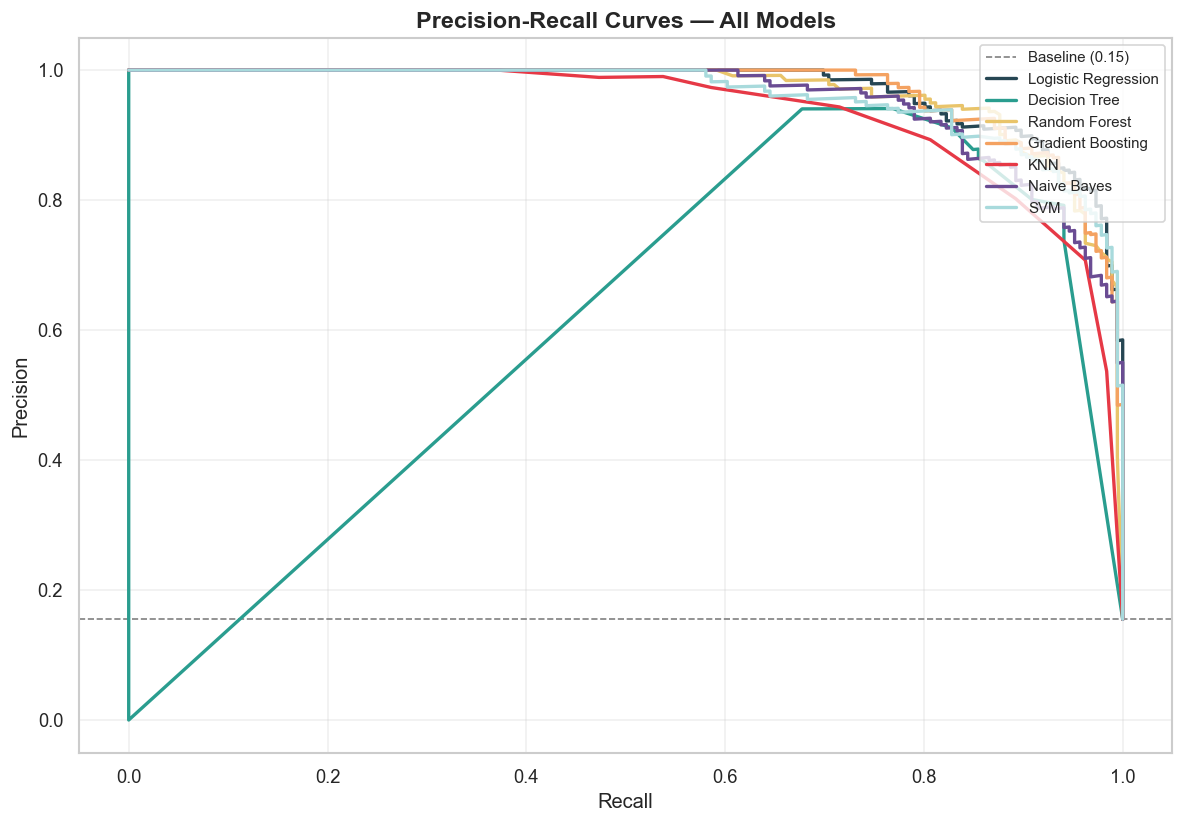

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
base_precision = y_test.mean()
ax.axhline(base_precision, color='grey', linestyle='--', linewidth=1,
           label=f'Baseline ({base_precision:.2f})')

for (name, res), color in zip(results.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, linewidth=2, color=color, label=name)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 22. Confusion Matrices

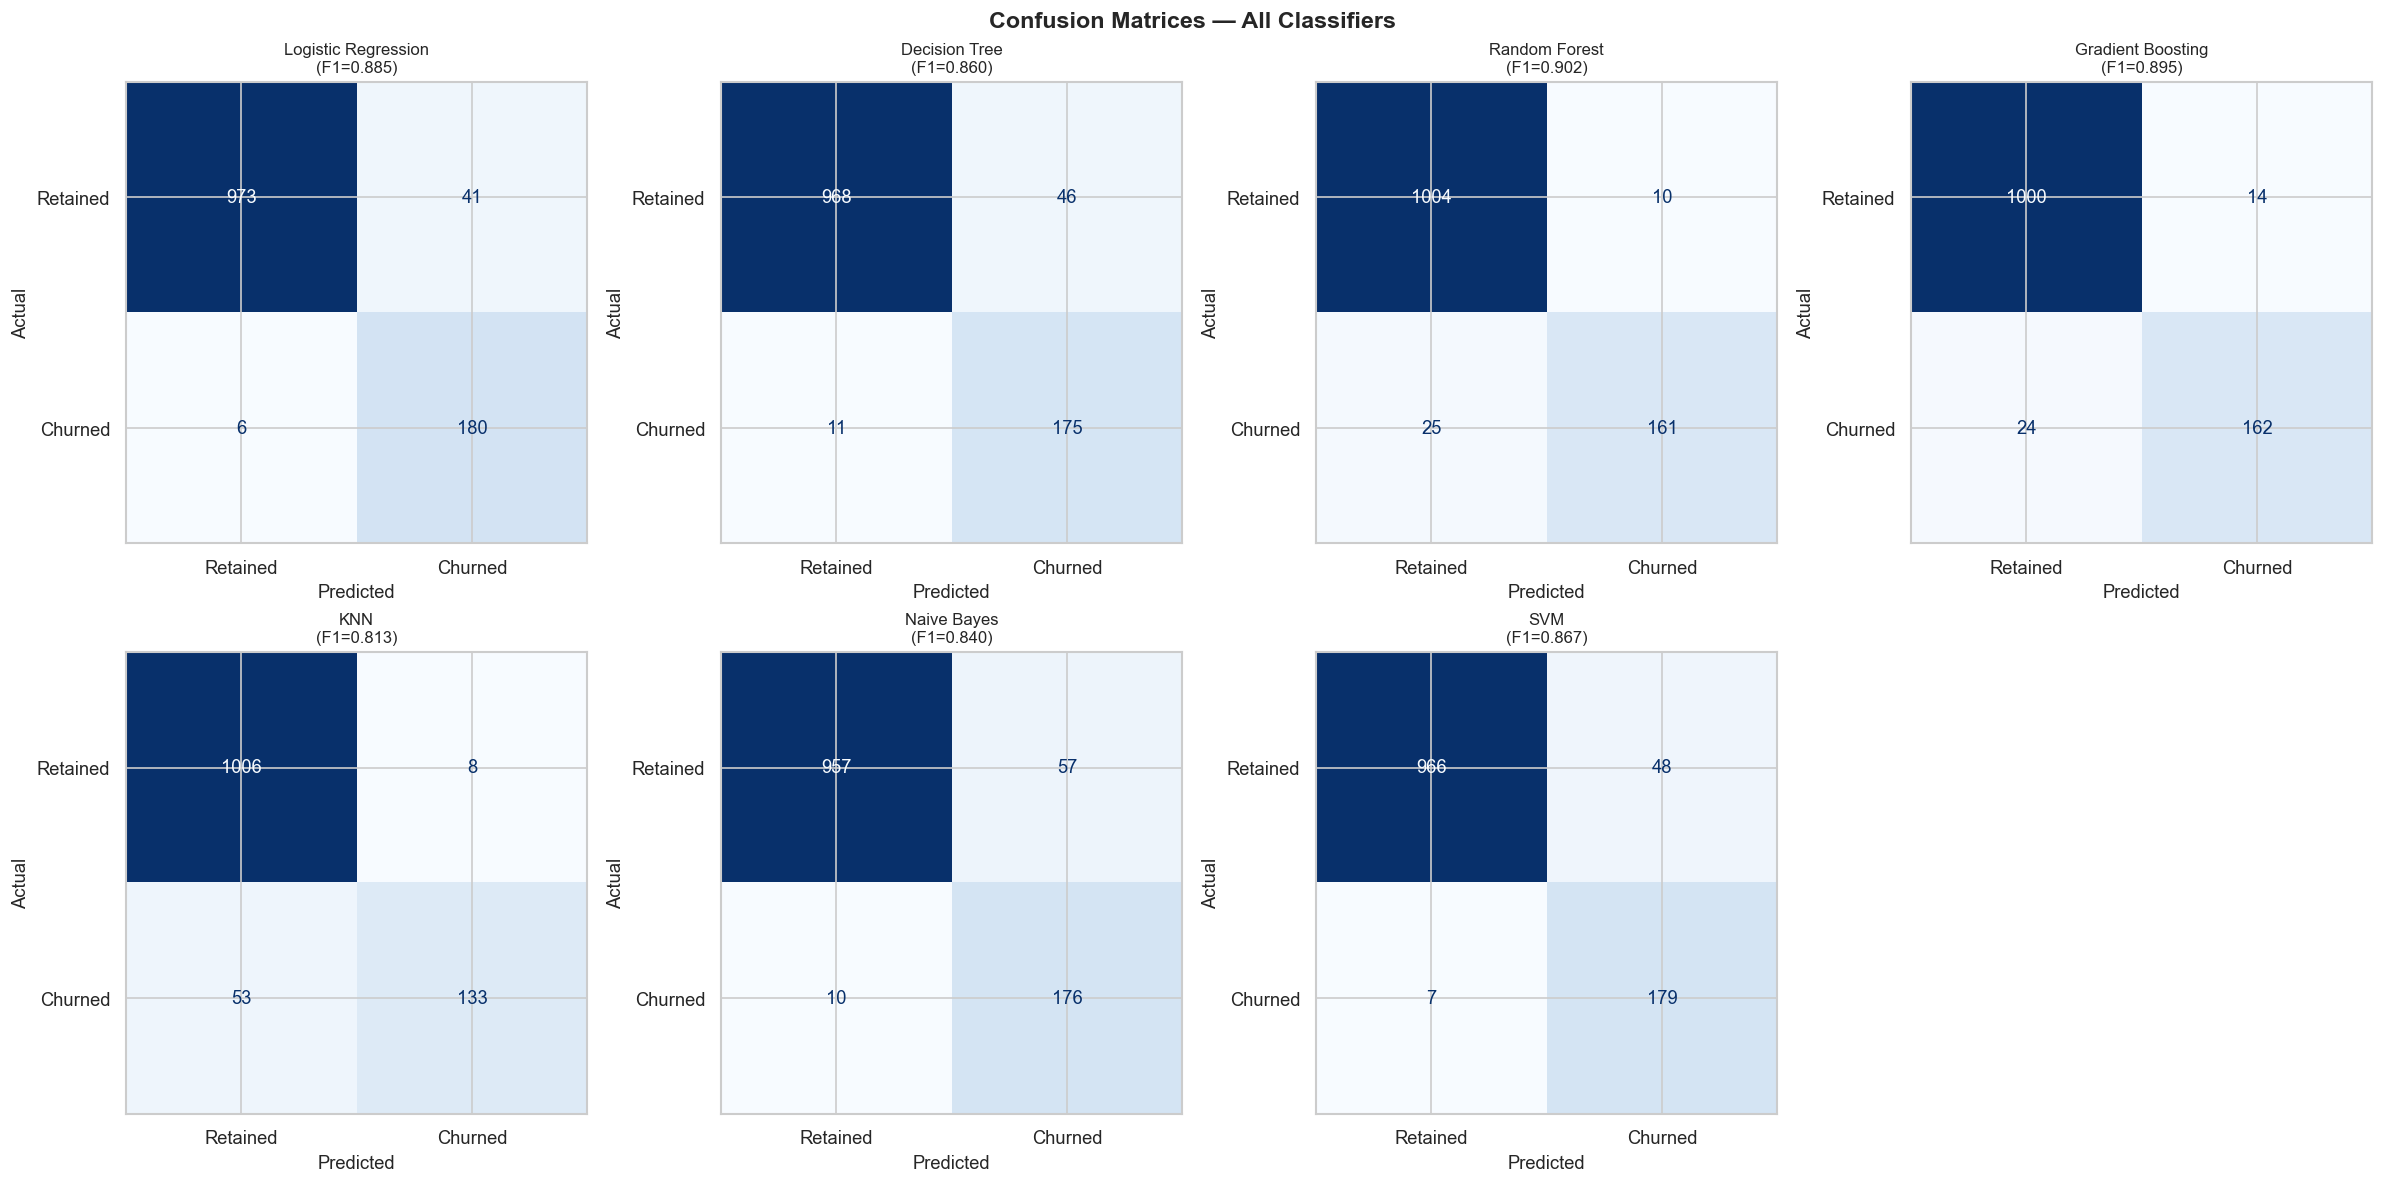

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\n(F1={res["f1"]:.3f})', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 23. Feature Importance — Random Forest & Gradient Boosting

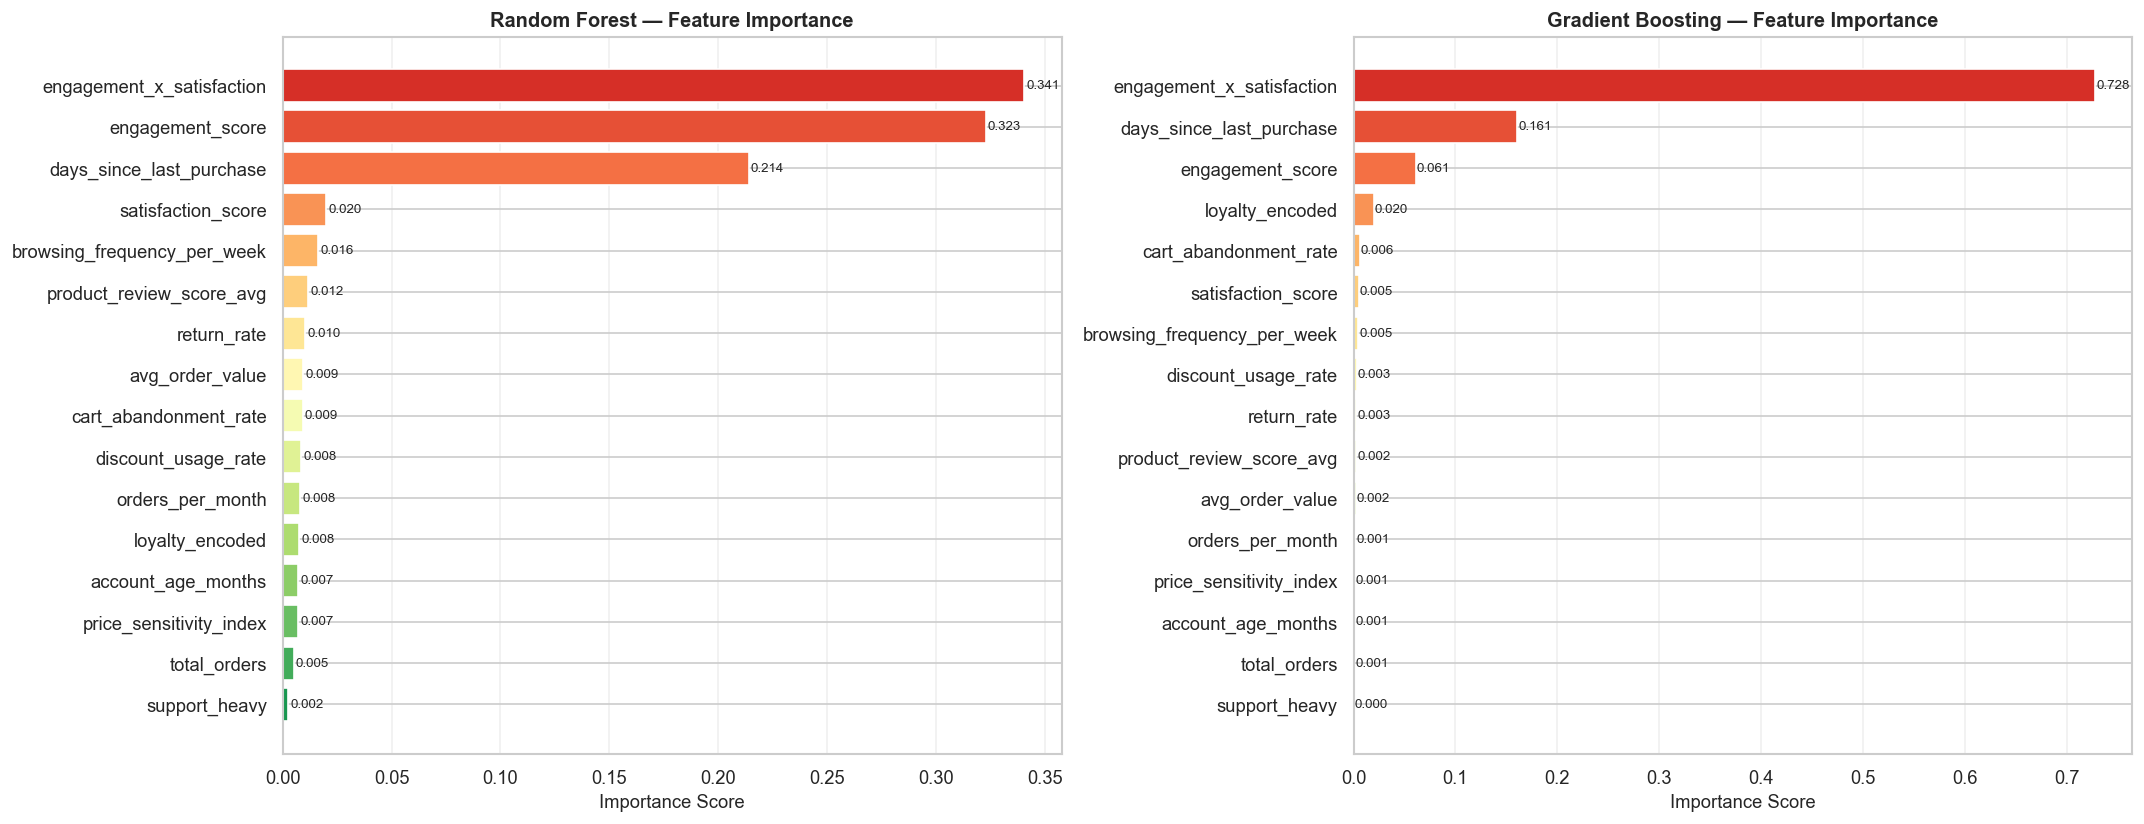

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model_name in zip(axes, ['Random Forest','Gradient Boosting']):
    clf = results[model_name]['model']
    importances = clf.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]
    sorted_feat = [feature_cols[i] for i in sorted_idx]
    sorted_imp  = importances[sorted_idx]

    colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sorted_feat)))
    bars = ax.barh(sorted_feat[::-1], sorted_imp[::-1], color=colors_fi, edgecolor='white')

    for bar, val in zip(bars, sorted_imp[::-1]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

    ax.set_title(f'{model_name} — Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 24. Learning Curves (Best Model)

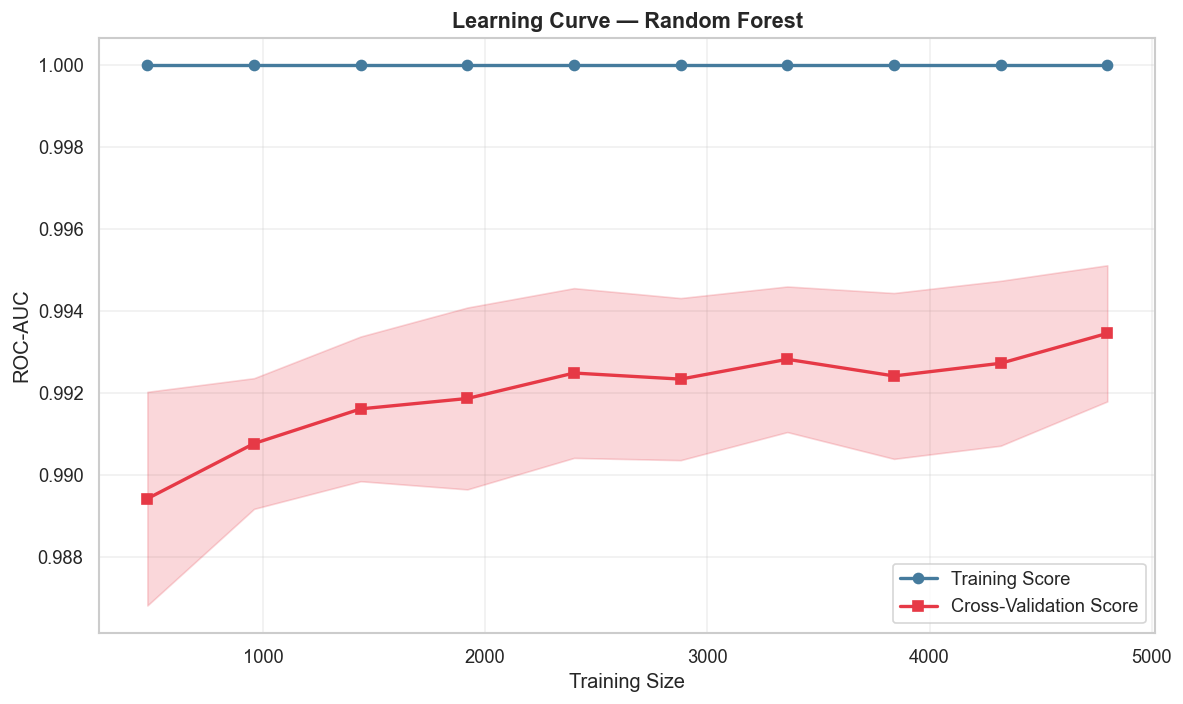

In [25]:
from sklearn.model_selection import learning_curve

best_clf = results['Random Forest']['model']
train_sizes, train_scores, val_scores = learning_curve(
    best_clf, X, y, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color=PALETTE['retain'],
        linewidth=2, label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                color=PALETTE['retain'], alpha=0.2)
ax.plot(train_sizes, val_mean, 's-', color=PALETTE['churn'],
        linewidth=2, label='Cross-Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                color=PALETTE['churn'], alpha=0.2)
ax.set_xlabel('Training Size', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Learning Curve — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 25. Cross-Validation Comparison

Logistic Regression   : 0.9958 ± 0.0008
Decision Tree         : 0.9681 ± 0.0067
Random Forest         : 0.9930 ± 0.0029
Gradient Boosting     : 0.9941 ± 0.0009
KNN                   : 0.9802 ± 0.0056
Naive Bayes           : 0.9925 ± 0.0015
SVM                   : 0.9926 ± 0.0018


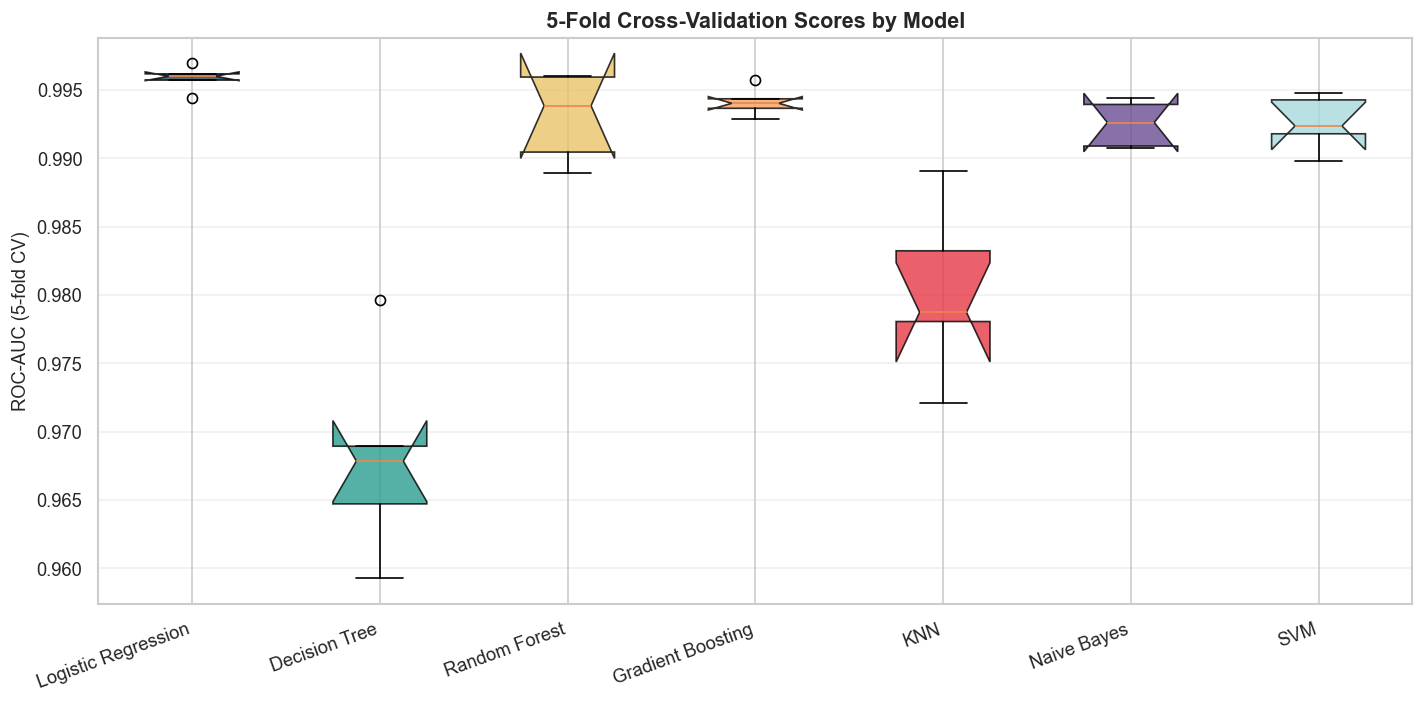

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, res in results.items():
    clf = res['model']
    if name in ['KNN','SVM','Naive Bayes']:
        scores = cross_val_score(clf, X_train_s, y_train, cv=cv,
                                 scoring='roc_auc', n_jobs=-1)
    else:
        scores = cross_val_score(clf, X_train, y_train, cv=cv,
                                 scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot([cv_results[n] for n in model_names],
                labels=model_names, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors_roc):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('5-Fold Cross-Validation Scores by Model', fontsize=13, fontweight='bold')
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 26. Probability Distribution — Best Model

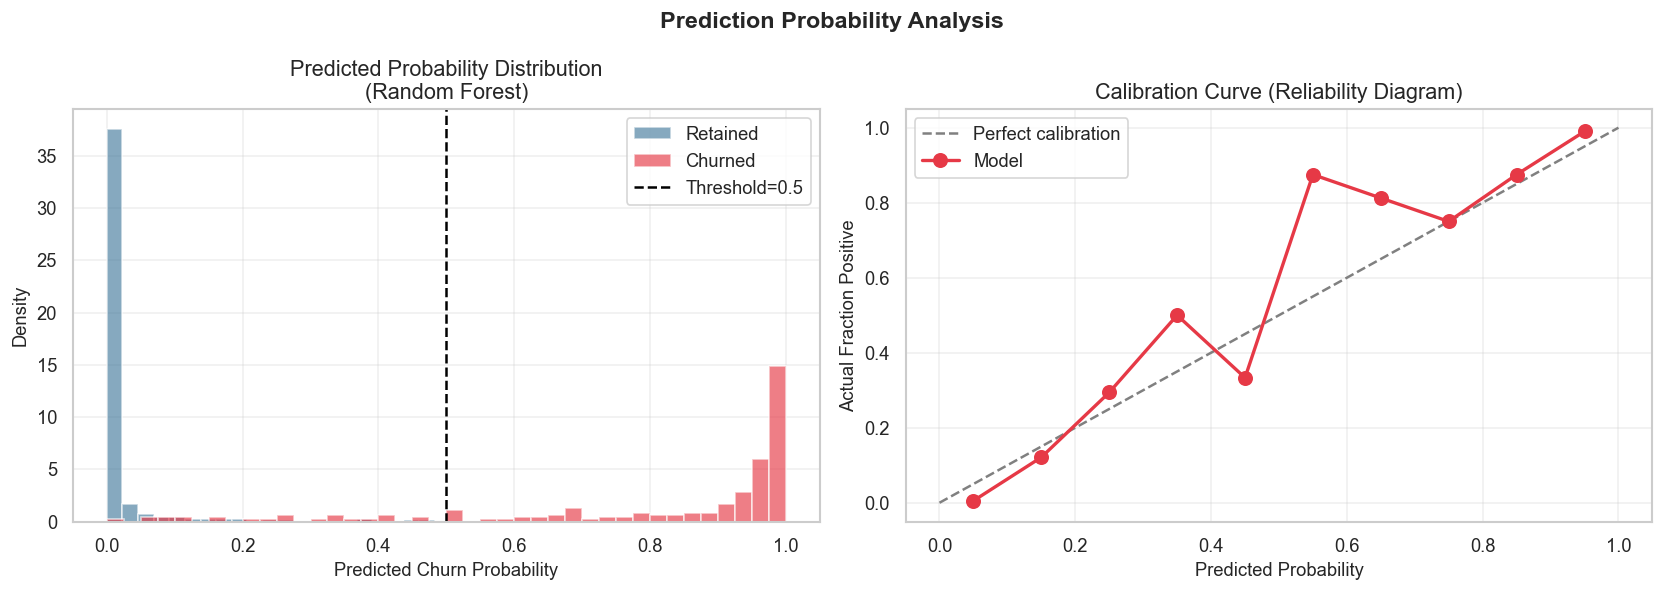

In [ ]:
best_probs = results['Random Forest']['y_prob']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for flag, label, color in [(0,'Retained',PALETTE['retain']),(1,'Churned',PALETTE['churn'])]:
    mask = y_test == flag
    axes[0].hist(best_probs[mask], bins=40, alpha=0.65,
                 label=label, color=color, density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold=0.5')
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Predicted Probability Distribution\n(Random Forest)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

bins = np.linspace(0, 1, 11)
bin_accs, bin_mids = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (best_probs >= lo) & (best_probs < hi)
    if mask.sum() > 0:
        bin_accs.append(y_test[mask].mean())
        bin_mids.append((lo+hi)/2)

axes[1].plot([0,1],[0,1],'--', color='grey', label='Perfect calibration')
axes[1].plot(bin_mids, bin_accs, 'o-', color=PALETTE['churn'],
             linewidth=2, markersize=8, label='Model')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Actual Fraction Positive')
axes[1].set_title('Calibration Curve (Reliability Diagram)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Prediction Probability Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 27. Threshold Sensitivity Analysis

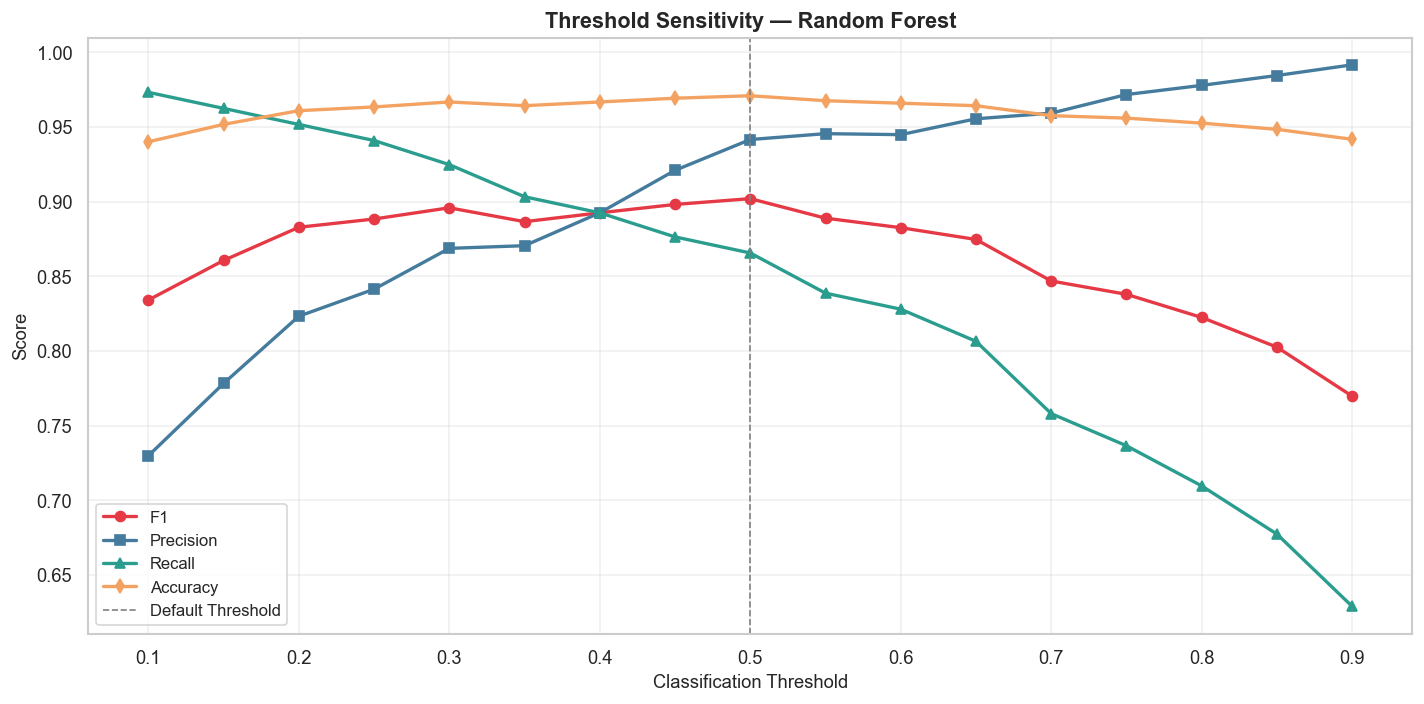

In [28]:
thresholds = np.arange(0.1, 0.91, 0.05)
th_f1, th_prec, th_rec, th_acc = [], [], [], []

for th in thresholds:
    y_pred_th = (best_probs >= th).astype(int)
    th_f1.append(f1_score(y_test, y_pred_th, zero_division=0))
    th_prec.append(precision_score(y_test, y_pred_th, zero_division=0))
    th_rec.append(recall_score(y_test, y_pred_th, zero_division=0))
    th_acc.append(accuracy_score(y_test, y_pred_th))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, th_f1,   'o-', label='F1',        color='#E63946', linewidth=2)
ax.plot(thresholds, th_prec, 's-', label='Precision', color='#457B9D', linewidth=2)
ax.plot(thresholds, th_rec,  '^-', label='Recall',    color='#2A9D8F', linewidth=2)
ax.plot(thresholds, th_acc,  'd-', label='Accuracy',  color='#F4A261', linewidth=2)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, label='Default Threshold')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 28. Analytical Dashboard — Multi-Panel Real-Time Style

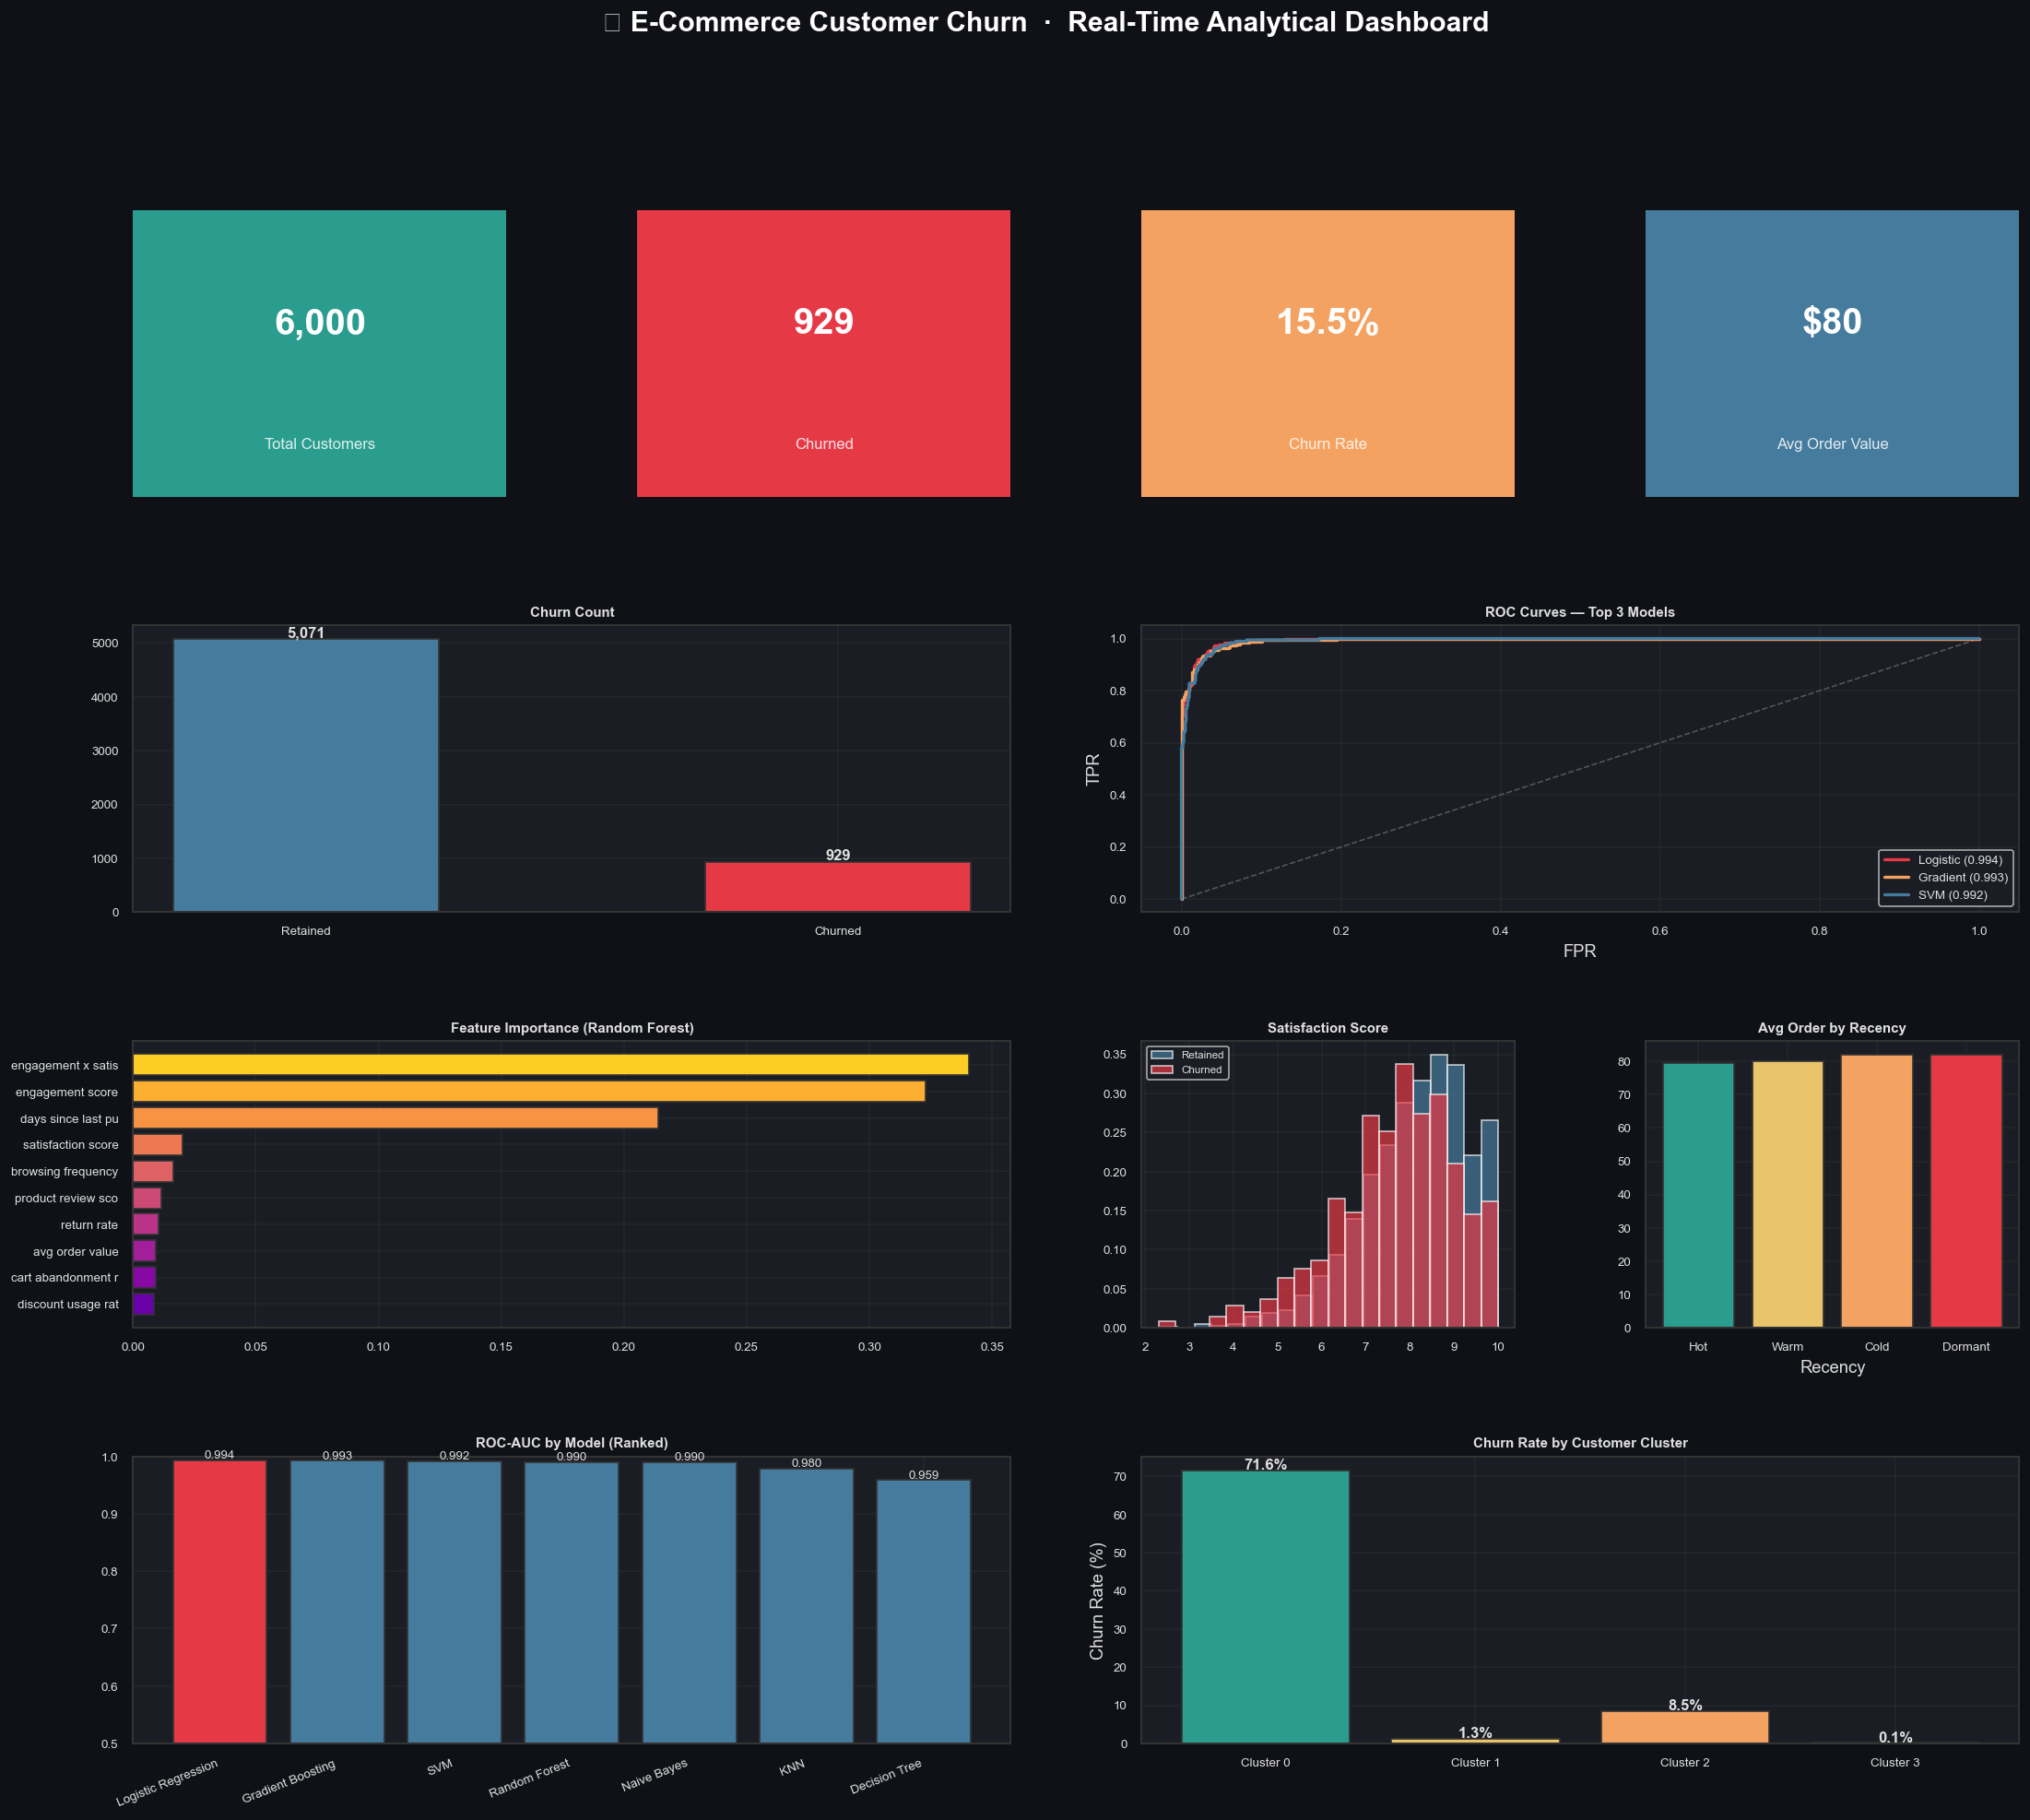

✅ Dashboard saved to dashboard.png


In [ ]:
fig = plt.figure(figsize=(22, 18), facecolor='#0F1117')
fig.suptitle('🛒 E-Commerce Customer Churn  ·  Real-Time Analytical Dashboard',
             fontsize=18, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35)

dark_ax  = '#1A1D23'
txt_col  = '#E0E0E0'

def style_dark(ax, title=''):
    ax.set_facecolor(dark_ax)
    ax.tick_params(colors=txt_col, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#333')
    if title:
        ax.set_title(title, color=txt_col, fontsize=9, fontweight='bold', pad=6)
    ax.xaxis.label.set_color(txt_col)
    ax.yaxis.label.set_color(txt_col)
    ax.grid(True, alpha=0.15, color='#555')

kpi_defs = [
    (f'{total:,}',    'Total Customers',   '#2A9D8F'),
    (f'{churned_n:,}','Churned',            '#E63946'),
    (f'{churn_rate:.1f}%','Churn Rate',      '#F4A261'),
    (f'${avg_order:.0f}','Avg Order Value',  '#457B9D'),
]
for col_i, (val, lbl, color) in enumerate(kpi_defs):
    ax_kpi = fig.add_subplot(gs[0, col_i])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.60, val, transform=ax_kpi.transAxes,
                ha='center', va='center', fontsize=24, fontweight='bold', color='white')
    ax_kpi.text(0.5, 0.18, lbl, transform=ax_kpi.transAxes,
                ha='center', va='center', fontsize=10, color='white', alpha=0.85)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    for sp in ax_kpi.spines.values(): sp.set_visible(False)

ax1 = fig.add_subplot(gs[1, 0:2])
counts_ = df['churn_flag'].value_counts()
bars_ = ax1.bar(['Retained','Churned'], counts_.values,
                color=[PALETTE['retain'], PALETTE['churn']], edgecolor='#333', width=0.5)
for bar, v in zip(bars_, counts_.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
             f'{v:,}', ha='center', color=txt_col, fontsize=10, fontweight='bold')
style_dark(ax1, 'Churn Count')

ax2 = fig.add_subplot(gs[1, 2:4])
ax2.plot([0,1],[0,1],'--', color='#555', linewidth=1)
top3 = sorted(results.items(), key=lambda x: x[1]['roc_auc'], reverse=True)[:3]
roc_cols = [PALETTE['churn'],'#F4A261',PALETTE['retain']]
for (name, res), col in zip(top3, roc_cols):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax2.plot(fpr, tpr, color=col, linewidth=2,
             label=f"{name.split()[0]} ({res['roc_auc']:.3f})")
style_dark(ax2, 'ROC Curves — Top 3 Models')
ax2.legend(fontsize=8, labelcolor=txt_col, facecolor=dark_ax)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')

ax3 = fig.add_subplot(gs[2, 0:2])
rf_clf   = results['Random Forest']['model']
fi       = rf_clf.feature_importances_
fi_idx   = np.argsort(fi)
fi_names = [feature_cols[i].replace('_',' ')[:18] for i in fi_idx[-10:]]
fi_vals  = fi[fi_idx[-10:]]
cmap_fi  = plt.cm.plasma(np.linspace(0.2, 0.9, 10))
ax3.barh(fi_names, fi_vals, color=cmap_fi, edgecolor='#333')
style_dark(ax3, 'Feature Importance (Random Forest)')

ax4 = fig.add_subplot(gs[2, 2])
for flag, label, color in [(0,'Retained',PALETTE['retain']),(1,'Churned',PALETTE['churn'])]:
    ax4.hist(df[df['churn_flag']==flag]['satisfaction_score'],
             bins=20, alpha=0.7, color=color, label=label, density=True)
style_dark(ax4, 'Satisfaction Score')
ax4.legend(fontsize=7, labelcolor=txt_col, facecolor=dark_ax)

ax5 = fig.add_subplot(gs[2, 3])
rec_avg = df.groupby('recency_bucket')['avg_order_value'].mean()
ax5.bar(rec_avg.index, rec_avg.values,
        color=['#2A9D8F','#E9C46A','#F4A261','#E63946'], edgecolor='#333')
style_dark(ax5, 'Avg Order by Recency')
ax5.set_xlabel('Recency')

ax6 = fig.add_subplot(gs[3, 0:2])
auc_s = [(n, results[n]['roc_auc']) for n in model_names]
auc_s.sort(key=lambda x: x[1], reverse=True)
ns, vs = zip(*auc_s)
bar_c6 = [PALETTE['churn'] if i==0 else '#457B9D' for i in range(len(ns))]
ax6.bar(ns, vs, color=bar_c6, edgecolor='#333')
ax6.set_ylim(0.5, 1.0)
ax6.set_xticklabels(ns, rotation=22, ha='right', fontsize=7)
for x, v in enumerate(vs):
    ax6.text(x, v+0.003, f'{v:.3f}', ha='center', color=txt_col, fontsize=8)
style_dark(ax6, 'ROC-AUC by Model (Ranked)')

ax7 = fig.add_subplot(gs[3, 2:4])
cl_churn = df.groupby('cluster')['churn_flag'].mean() * 100
colors_cl = ['#2A9D8F','#E9C46A','#F4A261','#E63946']
ax7.bar([f'Cluster {i}' for i in cl_churn.index], cl_churn.values,
        color=colors_cl, edgecolor='#333')
for x, v in enumerate(cl_churn.values):
    ax7.text(x, v+0.3, f'{v:.1f}%', ha='center', color=txt_col, fontsize=10, fontweight='bold')
style_dark(ax7, 'Churn Rate by Customer Cluster')
ax7.set_ylabel('Churn Rate (%)')

fig.patch.set_facecolor('#0F1117')
plt.savefig('dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('✅ Dashboard saved to dashboard.png')

## 29. Plotly Interactive Dashboard (if available)

In [ ]:
if PLOTLY:
    fig_px = make_subplots(
        rows=3, cols=3,
        subplot_titles=[
            'Churn Distribution','Satisfaction by Churn','Avg Order by Recency',
            'ROC Curves (Top 3)','Feature Importance','Churn Rate by Cluster',
            'Cart Abandonment vs Engagement','Model ROC-AUC Comparison','Prob Distribution'
        ],
        specs=[[{'type':'bar'},{'type':'box'},{'type':'bar'}],
               [{'type':'scatter'},{'type':'bar'},{'type':'bar'}],
               [{'type':'scatter'},{'type':'bar'},{'type':'histogram'}]]
    )
    for flag, label, color in [(0,'Retained','#457B9D'),(1,'Churned','#E63946')]:
        cnt = (df['churn_flag']==flag).sum()
        fig_px.add_trace(go.Bar(name=label, x=[label], y=[cnt],
                                 marker_color=color, showlegend=True), row=1, col=1)
    for flag, label, color in [(0,'Retained','#457B9D'),(1,'Churned','#E63946')]:
        fig_px.add_trace(go.Box(
            y=df[df['churn_flag']==flag]['satisfaction_score'],
            name=label, marker_color=color, showlegend=False
        ), row=1, col=2)

    rec_avg = df.groupby('recency_bucket')['avg_order_value'].mean()
    fig_px.add_trace(go.Bar(x=rec_avg.index.astype(str), y=rec_avg.values,
                             marker_color=['#2A9D8F','#E9C46A','#F4A261','#E63946'],
                             showlegend=False), row=1, col=3)
    for (name, res), color in zip(top3, ['#E63946','#F4A261','#457B9D']):
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        fig_px.add_trace(go.Scatter(
            x=fpr, y=tpr, mode='lines',
            name=f"{name.split()[0]} AUC={res['roc_auc']:.3f}",
            line=dict(color=color, width=2), showlegend=True
        ), row=2, col=1)
    fig_px.add_trace(go.Scatter(x=[0,1],y=[0,1],mode='lines',
                                 line=dict(dash='dash',color='grey'),
                                 showlegend=False), row=2, col=1)

    fi_sorted = sorted(zip(feature_cols, rf_clf.feature_importances_),
                       key=lambda x: x[1], reverse=True)[:10]
    fi_n, fi_v = zip(*fi_sorted)
    fig_px.add_trace(go.Bar(
        x=fi_v, y=[n.replace('_',' ') for n in fi_n],
        orientation='h', marker_color='#6A4C93', showlegend=False
    ), row=2, col=2)

    cl_c = df.groupby('cluster')['churn_flag'].mean() * 100
    fig_px.add_trace(go.Bar(
        x=[f'C{i}' for i in cl_c.index], y=cl_c.values,
        marker_color=['#2A9D8F','#E9C46A','#F4A261','#E63946'],
        showlegend=False
    ), row=2, col=3)

    for flag, label, color in [(0,'Retained','#457B9D'),(1,'Churned','#E63946')]:
        sub = df[df['churn_flag']==flag].sample(300, random_state=42)
        fig_px.add_trace(go.Scatter(
            x=sub['cart_abandonment_rate'], y=sub['engagement_score'],
            mode='markers', name=label, marker=dict(color=color, size=5, opacity=0.6),
            showlegend=False
        ), row=3, col=1)

    fig_px.add_trace(go.Bar(
        x=[n for n,_ in auc_s], y=[v for _,v in auc_s],
        marker_color='#1D3557', showlegend=False
    ), row=3, col=2)

    for flag, label, color in [(0,'Retained','#457B9D'),(1,'Churned','#E63946')]:
        mask = y_test == flag
        fig_px.add_trace(go.Histogram(
            x=best_probs[mask], name=label, nbinsx=40,
            marker_color=color, opacity=0.6, showlegend=False
        ), row=3, col=3)

    fig_px.update_layout(
        height=1000, width=1400,
        title_text='🛒 Interactive E-Commerce Churn Dashboard (Plotly)',
        template='plotly_dark',
        barmode='overlay'
    )
    fig_px.show()
else:
    print('Plotly not available. Install with: pip install plotly')

## 30. PostgreSQL Schema & Seed Script

In [33]:
sql_schema = '''
-- ============================================================
--  E-Commerce Churn Analytics — PostgreSQL Schema
--  Generated automatically from the ML notebook
-- ============================================================

-- Drop & recreate
DROP TABLE IF EXISTS model_predictions CASCADE;
DROP TABLE IF EXISTS customer_clusters  CASCADE;
DROP TABLE IF EXISTS customers          CASCADE;

-- ── Core customer table ──────────────────────────────────────
CREATE TABLE customers (
    customer_id                UUID         PRIMARY KEY,
    account_age_months         INTEGER      NOT NULL CHECK (account_age_months >= 0),
    avg_order_value            NUMERIC(10,2) NOT NULL,
    total_orders               INTEGER      NOT NULL CHECK (total_orders >= 0),
    days_since_last_purchase   INTEGER      NOT NULL CHECK (days_since_last_purchase >= 0),
    discount_usage_rate        NUMERIC(5,4) NOT NULL CHECK (discount_usage_rate BETWEEN 0 AND 1),
    return_rate                NUMERIC(5,4) NOT NULL CHECK (return_rate BETWEEN 0 AND 1),
    customer_support_tickets   INTEGER      NOT NULL DEFAULT 0,
    loyalty_member             BOOLEAN      NOT NULL DEFAULT FALSE,
    browsing_frequency_per_week NUMERIC(5,2) NOT NULL,
    cart_abandonment_rate      NUMERIC(5,4) NOT NULL CHECK (cart_abandonment_rate BETWEEN 0 AND 1),
    product_review_score_avg   NUMERIC(4,2),
    engagement_score           NUMERIC(5,2),
    satisfaction_score         NUMERIC(5,2),
    price_sensitivity_index    NUMERIC(4,2),
    -- Engineered features
    orders_per_month           NUMERIC(8,4) GENERATED ALWAYS AS
                                 (total_orders::NUMERIC / NULLIF(account_age_months,0)) STORED,
    engagement_x_satisfaction  NUMERIC(8,4) GENERATED ALWAYS AS
                                 (engagement_score * satisfaction_score) STORED,
    -- Target
    churned                    BOOLEAN      NOT NULL DEFAULT FALSE,
    -- Metadata
    created_at                 TIMESTAMPTZ  DEFAULT NOW(),
    updated_at                 TIMESTAMPTZ  DEFAULT NOW()
);

-- ── Customer segments / clusters ─────────────────────────────
CREATE TABLE customer_clusters (
    customer_id   UUID     PRIMARY KEY REFERENCES customers(customer_id) ON DELETE CASCADE,
    cluster_id    SMALLINT NOT NULL CHECK (cluster_id BETWEEN 0 AND 9),
    recency_bucket VARCHAR(10) CHECK (recency_bucket IN ('Hot','Warm','Cold','Dormant')),
    value_segment  VARCHAR(10) CHECK (value_segment   IN ('Low','Mid','High','Premium')),
    assigned_at   TIMESTAMPTZ DEFAULT NOW()
);

-- ── ML model predictions ─────────────────────────────────────
CREATE TABLE model_predictions (
    prediction_id    BIGSERIAL PRIMARY KEY,
    customer_id      UUID         NOT NULL REFERENCES customers(customer_id),
    model_name       VARCHAR(64)  NOT NULL,
    model_version    VARCHAR(32)  NOT NULL DEFAULT '1.0.0',
    churn_probability NUMERIC(6,5) NOT NULL CHECK (churn_probability BETWEEN 0 AND 1),
    predicted_churn  BOOLEAN      NOT NULL,
    threshold_used   NUMERIC(4,3) NOT NULL DEFAULT 0.500,
    predicted_at     TIMESTAMPTZ  DEFAULT NOW()
);

-- ── Indexes ──────────────────────────────────────────────────
CREATE INDEX idx_customers_churned         ON customers (churned);
CREATE INDEX idx_customers_loyalty         ON customers (loyalty_member);
CREATE INDEX idx_customers_satisfaction    ON customers (satisfaction_score);
CREATE INDEX idx_clusters_cluster_id       ON customer_clusters (cluster_id);
CREATE INDEX idx_predictions_customer      ON model_predictions (customer_id);
CREATE INDEX idx_predictions_model         ON model_predictions (model_name, predicted_at);
CREATE INDEX idx_predictions_churn_prob    ON model_predictions (churn_probability DESC);

-- ── Auto-update updated_at ───────────────────────────────────
CREATE OR REPLACE FUNCTION update_updated_at()
RETURNS TRIGGER AS $$
BEGIN NEW.updated_at = NOW(); RETURN NEW; END;
$$ LANGUAGE plpgsql;

CREATE TRIGGER trg_customers_updated_at
    BEFORE UPDATE ON customers
    FOR EACH ROW EXECUTE FUNCTION update_updated_at();

-- ── Dashboard Views ──────────────────────────────────────────
CREATE OR REPLACE VIEW vw_churn_kpis AS
SELECT
    COUNT(*)                                   AS total_customers,
    SUM(churned::INT)                          AS total_churned,
    ROUND(AVG(churned::INT) * 100, 2)          AS churn_rate_pct,
    ROUND(AVG(avg_order_value), 2)             AS avg_order_value,
    ROUND(AVG(satisfaction_score), 2)          AS avg_satisfaction,
    SUM(loyalty_member::INT)                   AS loyalty_members,
    ROUND(AVG(loyalty_member::INT) * 100, 2)   AS loyalty_pct
FROM customers;

CREATE OR REPLACE VIEW vw_churn_by_segment AS
SELECT
    cc.value_segment,
    cc.recency_bucket,
    COUNT(*)                                   AS n_customers,
    SUM(c.churned::INT)                        AS n_churned,
    ROUND(AVG(c.churned::INT) * 100, 2)        AS churn_rate_pct,
    ROUND(AVG(c.avg_order_value), 2)           AS avg_order_value,
    ROUND(AVG(c.satisfaction_score), 2)        AS avg_satisfaction
FROM customers c
JOIN customer_clusters cc USING (customer_id)
GROUP BY cc.value_segment, cc.recency_bucket
ORDER BY churn_rate_pct DESC;

CREATE OR REPLACE VIEW vw_high_risk_customers AS
SELECT
    c.customer_id,
    c.satisfaction_score,
    c.engagement_score,
    c.days_since_last_purchase,
    c.cart_abandonment_rate,
    p.churn_probability,
    cc.recency_bucket,
    cc.value_segment
FROM customers c
JOIN model_predictions p USING (customer_id)
JOIN customer_clusters cc USING (customer_id)
WHERE p.churn_probability >= 0.7
  AND p.model_name = 'random_forest'
ORDER BY p.churn_probability DESC;

CREATE OR REPLACE VIEW vw_cluster_summary AS
SELECT
    cc.cluster_id,
    COUNT(*)                             AS n_customers,
    ROUND(AVG(c.churned::INT)*100, 2)    AS churn_rate_pct,
    ROUND(AVG(c.avg_order_value), 2)     AS avg_order_value,
    ROUND(AVG(c.satisfaction_score), 2)  AS avg_satisfaction,
    ROUND(AVG(c.engagement_score), 2)    AS avg_engagement
FROM customers c
JOIN customer_clusters cc USING (customer_id)
GROUP BY cc.cluster_id
ORDER BY churn_rate_pct DESC;
'''

print(sql_schema)


-- ============================================================
--  E-Commerce Churn Analytics — PostgreSQL Schema
--  Generated automatically from the ML notebook
-- ============================================================

-- Drop & recreate
DROP TABLE IF EXISTS model_predictions CASCADE;
DROP TABLE IF EXISTS customer_clusters  CASCADE;
DROP TABLE IF EXISTS customers          CASCADE;

-- ── Core customer table ──────────────────────────────────────
CREATE TABLE customers (
    customer_id                UUID         PRIMARY KEY,
    account_age_months         INTEGER      NOT NULL CHECK (account_age_months >= 0),
    avg_order_value            NUMERIC(10,2) NOT NULL,
    total_orders               INTEGER      NOT NULL CHECK (total_orders >= 0),
    days_since_last_purchase   INTEGER      NOT NULL CHECK (days_since_last_purchase >= 0),
    discount_usage_rate        NUMERIC(5,4) NOT NULL CHECK (discount_usage_rate BETWEEN 0 AND 1),
    return_rate                NUMERIC(5,4) NO

In [ ]:
with open('churn_analytics_schema.sql', 'w') as f:
    f.write(sql_schema)
print('✅ SQL schema written to churn_analytics_schema.sql')

seed_df = df[['Customer_ID','account_age_months','avg_order_value','total_orders',
              'days_since_last_purchase','discount_usage_rate','return_rate',
              'customer_support_tickets','loyalty_encoded',
              'browsing_frequency_per_week','cart_abandonment_rate',
              'product_review_score_avg','engagement_score',
              'satisfaction_score','price_sensitivity_index','churn_flag',
              'cluster']].copy()

seed_df.rename(columns={
    'Customer_ID': 'customer_id',
    'loyalty_encoded': 'loyalty_member',
    'churn_flag': 'churned'
}, inplace=True)

seed_df.drop(columns=['cluster']).to_csv('customers_seed.csv', index=False)
print('✅ Seed CSV written to customers_seed.csv')
print(f'   → {len(seed_df):,} rows ready for: COPY customers FROM customers_seed.csv CSV HEADER;')

✅ SQL schema written to churn_analytics_schema.sql
✅ Seed CSV written to customers_seed.csv
   → 6,000 rows ready for: COPY customers FROM customers_seed.csv CSV HEADER;


## 31. Final Model Summary & Recommendations

In [32]:
best_name = max(results, key=lambda n: results[n]['roc_auc'])
best_res  = results[best_name]

print('=' * 60)
print('  FINAL MODEL REPORT — E-Commerce Churn Prediction')
print('=' * 60)
print(f'  Dataset : 6,000 customers, 14 raw + 4 engineered features')
print(f'  Churn Rate (overall): {churn_rate:.1f}%')
print()
print(f'  🏆 Best Model : {best_name}')
print(f'     Accuracy   : {best_res["accuracy"]:.4f}')
print(f'     F1 Score   : {best_res["f1"]:.4f}')
print(f'     Precision  : {best_res["precision"]:.4f}')
print(f'     Recall     : {best_res["recall"]:.4f}')
print(f'     ROC-AUC    : {best_res["roc_auc"]:.4f}')
print()
print('  Key Churn Drivers (from feature importance):')
top_fi = sorted(zip(feature_cols, rf_clf.feature_importances_),
                key=lambda x: x[1], reverse=True)[:5]
for rank, (feat, imp) in enumerate(top_fi, 1):
    print(f'     {rank}. {feat.replace("_"," ").title():<35} {imp:.4f}')
print()
print('  Business Recommendations:')
print('     • Target high-risk customers (prob ≥ 0.70) with retention offers')
print('     • Improve satisfaction for Dormant-segment customers')
print('     • Loyalty programmes reduce churn — expand eligibility')
print('     • Reduce cart abandonment via targeted email nudges')
print('     • High support-ticket customers need proactive outreach')
print()
print('  Output Files:')
print('     📊 dashboard.png              — Static analytical dashboard')
print('     🗄️  churn_analytics_schema.sql — PostgreSQL schema + views')
print('     📂  customers_seed.csv         — 6,000-row DB seed file')
print('=' * 60)

  FINAL MODEL REPORT — E-Commerce Churn Prediction
  Dataset : 6,000 customers, 14 raw + 4 engineered features
  Churn Rate (overall): 15.5%

  🏆 Best Model : Logistic Regression
     Accuracy   : 0.9608
     F1 Score   : 0.8845
     Precision  : 0.8145
     Recall     : 0.9677
     ROC-AUC    : 0.9939

  Key Churn Drivers (from feature importance):
     1. Engagement X Satisfaction           0.3406
     2. Engagement Score                    0.3228
     3. Days Since Last Purchase            0.2139
     4. Satisfaction Score                  0.0201
     5. Browsing Frequency Per Week         0.0164

  Business Recommendations:
     • Target high-risk customers (prob ≥ 0.70) with retention offers
     • Improve satisfaction for Dormant-segment customers
     • Loyalty programmes reduce churn — expand eligibility
     • Reduce cart abandonment via targeted email nudges
     • High support-ticket customers need proactive outreach

  Output Files:
     📊 dashboard.png              — Stati